# BVA Qudit Analysis

This notebook reads BVA summary logs from `Z:\Lab Data\Algorithms\QuDit_BVA\BVA_logs` in read-only mode.
It filters by qudit `dimension`, `LT_comp`, and `date_time`, then reproduces the same style of analysis as the existing BVA notebook.


In [2]:
from pathlib import Path
import re
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True

LOG_ROOT = Path(r"Z:\Lab Data\Algorithms\QuDit_BVA\BVA_logs")

# User inputs.
dimension = 13
LT_comp = True
date_time = "20260410_1618"
date_time = "20260410_1535"

print(f"Using read-only log directory: {LOG_ROOT}")
print(f"dimension = {dimension}")
print(f"LT_comp = {LT_comp}")
print(f"date_time = {date_time}")


def parse_population_line(line):
    line = line.strip()
    if line.startswith('[') and line.endswith(']'):
        line = line[1:-1]
    values = np.fromstring(line, sep=' ')
    return values


def parse_hidden_value(hidden_token):
    token = str(hidden_token).strip()
    if token == "":
        raise ValueError("hidden token is empty")
    try:
        return int(token)
    except ValueError as exc:
        raise ValueError(f"Could not parse hidden value '{token}' as an integer") from exc


def parse_log_filename(path):
    base = Path(path).name
    dim_match = re.search(r"BVA_(\d+)_", base, flags=re.IGNORECASE)
    hidden_match = re.search(r"hiddenval_([^_]+)", base, flags=re.IGNORECASE)
    lt_match = re.search(r"LT_comp_(True|False)", base, flags=re.IGNORECASE)
    dt_matches = re.findall(r"(\d{8}_\d{4,6})", base)

    if dim_match is None or hidden_match is None or not dt_matches:
        return None

    hidden_token = hidden_match.group(1)
    try:
        hidden_value = parse_hidden_value(hidden_token)
    except ValueError:
        return None

    return {
        "filename": base,
        "dimension": int(dim_match.group(1)),
        "hidden_token": hidden_token,
        "hidden_value": hidden_value,
        "lt_comp": None if lt_match is None else (lt_match.group(1) == "True"),
        "date_time": dt_matches[-1],
    }


def load_qudit_bva_logs(log_root, dimension, LT_comp, date_time):
    log_root = Path(log_root)
    if not log_root.exists():
        raise FileNotFoundError(f"Log directory does not exist or is not accessible: {log_root}")

    matched_meta = []
    for path in sorted(log_root.glob("*")):
        if not path.is_file():
            continue
        meta = parse_log_filename(path)
        if meta is None:
            continue
        if meta["dimension"] != int(dimension):
            continue
        if meta["lt_comp"] is None or meta["lt_comp"] != bool(LT_comp):
            continue
        if str(date_time) not in meta["date_time"]:
            continue
        meta["path"] = str(path)
        matched_meta.append(meta)

    if not matched_meta:
        raise FileNotFoundError(
            "No matching BVA log files were found for the requested dimension / LT_comp / date_time filter."
        )

    pop_data = {}
    file_paths = {}
    summary_paths = {}

    for meta in matched_meta:
        path = Path(meta["path"])
        lines = path.read_text(encoding='utf-8').splitlines()
        if len(lines) < 2:
            print(f"Skipping {path.name}: file does not contain enough lines.")
            continue

        pop_vector = parse_population_line(lines[0])
        experiment_path = lines[-1].strip()
        hidden_value = meta["hidden_value"]

        pop_data[hidden_value] = pop_vector
        file_paths[hidden_value] = experiment_path
        summary_paths[hidden_value] = str(path)

    hidden_values = sorted(pop_data.keys())
    if not hidden_values:
        raise ValueError("Matching files were found, but none contained usable population data.")

    return hidden_values, pop_data, file_paths, summary_paths


hidden_values, pop_data, file_paths, summary_paths = load_qudit_bva_logs(
    LOG_ROOT,
    dimension=dimension,
    LT_comp=LT_comp,
    date_time=date_time,
)

print(f"Matched hidden values: {hidden_values}")
print(f"Matched file count: {len(hidden_values)}")
missing_hidden_values = [value for value in range(dimension) if value not in hidden_values]
print(f"Missing hidden values: {missing_hidden_values}")


Using read-only log directory: Z:\Lab Data\Algorithms\QuDit_BVA\BVA_logs
dimension = 13
LT_comp = True
date_time = 20260410_1535
Matched hidden values: [0, 1, 2, 3, 4, 5, 6, 7]
Matched file count: 8
Missing hidden values: [8, 9, 10, 11, 12]


12.5
(171, 14)
200
[0.         0.67251462 0.14619883 0.04093567 0.01754386 0.01169591
 0.01169591 0.00584795 0.01169591 0.00584795 0.01754386 0.01169591
 0.02923977 0.01754386]
9.5
(167, 14)
200
[0.         0.09580838 0.76646707 0.05389222 0.01197605 0.00598802
 0.00598802 0.00598802 0.00598802 0.00598802 0.         0.
 0.01197605 0.02994012]
10.5
(174, 14)
200
[0.         0.02873563 0.03448276 0.83333333 0.00574713 0.01149425
 0.00574713 0.02298851 0.02298851 0.00574713 0.         0.00574713
 0.00574713 0.01724138]
11.5
(163, 14)
200
[0.         0.00613497 0.03067485 0.01226994 0.8404908  0.04294479
 0.01840491 0.         0.00613497 0.00613497 0.00613497 0.01226994
 0.01226994 0.00613497]
11.5
(165, 14)
200
[0.         0.03636364 0.02424242 0.01818182 0.01212121 0.85454545
 0.02424242 0.         0.         0.01818182 0.00606061 0.
 0.         0.00606061]
10.5
(170, 14)
200
[0.         0.08823529 0.01176471 0.01764706 0.04117647 0.04117647
 0.52352941 0.04117647 0.04705882 0.11764706 0

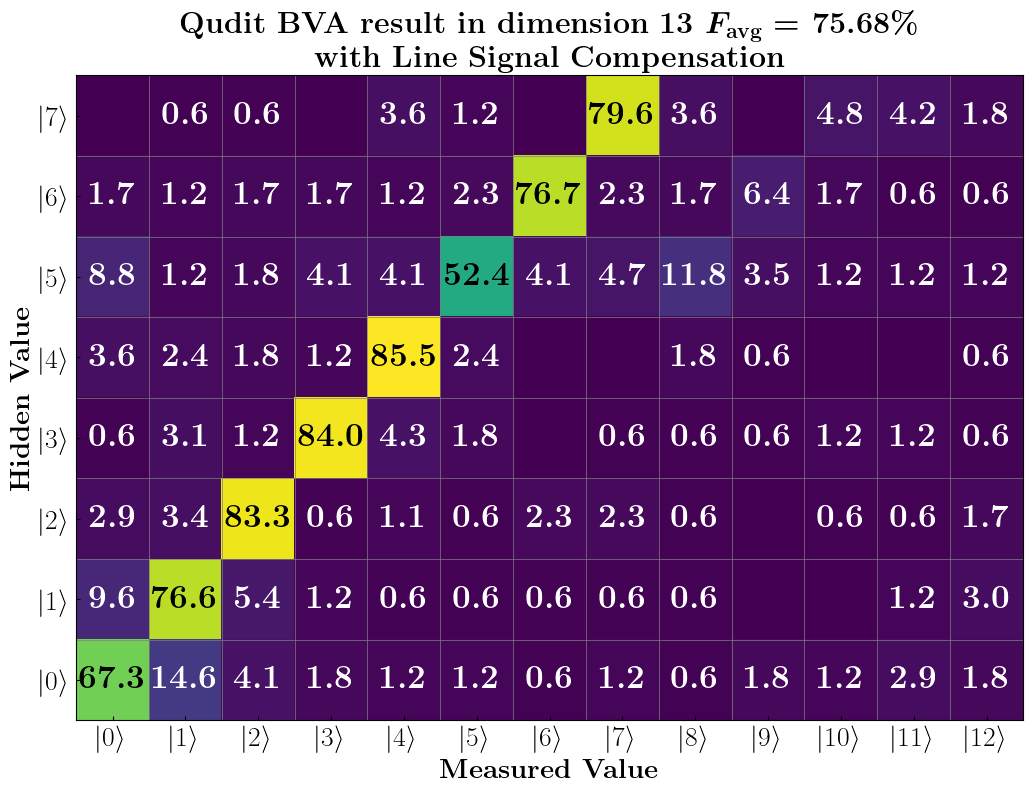

average fidelity = 0.7568412161293336
average detection rate = 0.8431249999999999


In [3]:
def load_experiment_from_file(path):
    exp = []
    with open(path, 'r') as f:
        for line in f:
            exp.append(json.loads(line)[0]["0"])
    return exp


def getShelvingThreshold(counts):
    ds = np.sort(counts, axis=None)
    if len(ds) > 4000:
        ds = ds[2000:]
    if len(ds) > 2000:
        st = round(ds.size / (len(counts) * 0.00150167))
        st = 1 if st < 1 else st
        ds = ds[0:-1:st]
    dsd = ds[1:-1] - ds[0:-2]
    th = max(dsd) / 2 + ds[np.argmax(dsd)]
    hc, be = np.histogram(counts, bins=range(4, 31))
    th = be[np.argmin(hc)] + 0.5
    if th < 2 or th > 20:
        th = 11.5
    return th, ds


keys = hidden_values
n_hidden = len(keys)
ket_avg = [None] * n_hidden
ket_dr = [0.0] * n_hidden
threshold_info = [None] * n_hidden

for row_index, hidden_value in enumerate(keys):
    experiment_path = file_paths[hidden_value]
    experiments = load_experiment_from_file(experiment_path)
    if len(experiments) == 0:
        continue

    experiments = np.asarray(experiments)
    flat_counts = experiments.ravel()
    try:
        threshold, _ = getShelvingThreshold(flat_counts)
        print(threshold)
    except Exception:
        threshold = None

    threshold_info[row_index] = (flat_counts, threshold, hidden_value)
    bright_mask = experiments > threshold
    resolved = np.full(bright_mask.shape, False, dtype=bool)
    for rep_index in range(bright_mask.shape[0]):
        transition_indices = np.where(bright_mask[rep_index])[0]
        # print(transition_indices)
        if transition_indices.size > 0 and transition_indices[0] != 0:
            # print("not empty")
            resolved[rep_index, transition_indices[0]] = True
    # display(resolved)
    valid_rows = resolved.any(axis=1)
    # print(valid_rows)
    filtered = resolved[valid_rows]
    print(filtered.shape)
    ket_dr[row_index] = filtered.shape[0] / experiments.shape[0]
    print(experiments.shape[0])
    if filtered.shape[0] > 0:
        ket_avg[row_index] = np.mean(filtered, axis=0)
        print(ket_avg[row_index])

meas_dim = next((len(vec) - 1 for vec in ket_avg if vec is not None and len(vec) > 1), dimension)
data_m = np.zeros((n_hidden, meas_dim), dtype=float)
for row_index in range(n_hidden):
    if ket_avg[row_index] is not None and len(ket_avg[row_index]) > 1:
        vector = ket_avg[row_index][1:]
        data_m[row_index, :min(len(vector), meas_dim)] = vector[:meas_dim]

fidelities = []
for row_index, hidden_value in enumerate(keys):
    if hidden_value < meas_dim and ket_avg[row_index] is not None:
        fidelities.append(data_m[row_index, hidden_value])

avg_fid = np.mean(fidelities) if fidelities else np.nan
avg_detection_rate = np.mean([value for value in ket_dr if value > 0]) if any(value > 0 for value in ket_dr) else np.nan

fig, ax = plt.subplots(figsize=(max(8, 0.8 * meas_dim), max(8, 0.6 * n_hidden)))
im = ax.imshow(data_m, cmap='viridis', aspect='auto')

hidden_labels = [rf'$|{value}\rangle$' for value in keys]
measured_labels = [rf'$|{value}\rangle$' for value in range(meas_dim)]
ax.set_xticks(np.arange(meas_dim))
ax.set_xticklabels(measured_labels, fontsize=20)
ax.set_yticks(np.arange(n_hidden))
ax.set_yticklabels(hidden_labels, fontsize=20)
ax.invert_yaxis()
ax.set_xlabel(r'\textbf{Measured Value}', fontsize=20)
ax.set_ylabel(r'\textbf{Hidden Value}', fontsize=20)

for row_index in range(n_hidden):
    if ket_avg[row_index] is None:
        ax.text(meas_dim / 2, row_index, r'\textbf{No Valid Data}', ha='center', va='center', color='red', fontsize=14)
    else:
        for col_index in range(meas_dim):
            if data_m[row_index, col_index] > 0.005:
                ax.text(
                    col_index,
                    row_index,
                    rf'\textbf{{{data_m[row_index, col_index] * 100:.1f}}}',
                    ha='center',
                    va='center',
                    color='black' if data_m[row_index, col_index] > 0.5 else 'white',
                    fontsize=24,
                )

for x in np.arange(-0.5, meas_dim, 1):
    ax.axvline(x, color='gray', linewidth=0.5)
for y in np.arange(-0.5, n_hidden, 1):
    ax.axhline(y, color='gray', linewidth=0.5)

line_label = r'\textbf{with Line Signal Compensation}' if LT_comp else r'\textbf{without Line Signal Compensation}'
ax.set_title(
    rf'\textbf{{Qudit BVA result in dimension {dimension} }}' +
    r'\boldmath$F_{\textbf{avg}}$' +
    rf'\textbf{{ = {100.0 * avg_fid:.2f}\%}}' + '\n' + line_label,
    fontsize=22,
)
plt.tight_layout()
plt.show()

print(f"average fidelity = {avg_fid}")
print(f"average detection rate = {avg_detection_rate}")


In [4]:
print(avg_fid)


0.7568412161293336


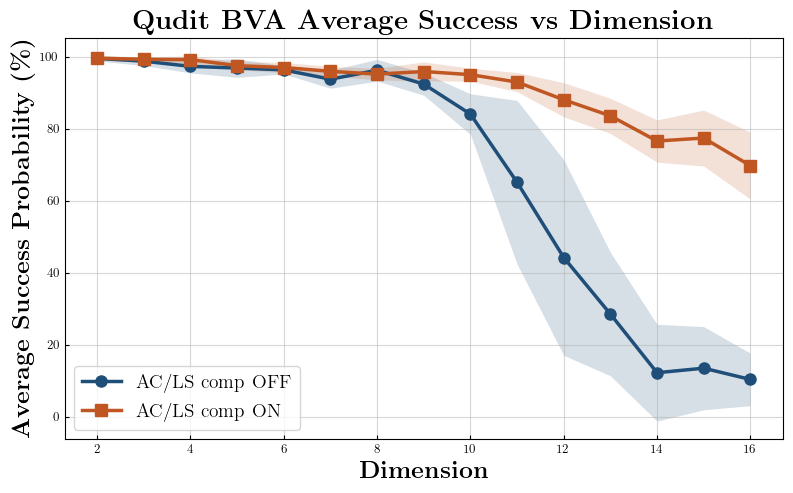

dimensions_by_lt = {False: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], True: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]}
avg_success_probability_by_lt = {False: [0.9959349593495934, 0.9880711002973777, 0.9737322897271097, 0.969017363405734, 0.9639547595933813, 0.937926940454995, 0.9629009858868413, 0.9244842009984081, 0.8411583550949931, 0.6518928598745126, 0.4428960692008317, 0.28591733700219324, 0.12300996210611984, 0.13560204213290114, 0.10434455285727108], True: [0.9964539007092199, 0.993073172487001, 0.992423853963696, 0.9756121877483279, 0.9704999285049968, 0.959819106362361, 0.9520451649827825, 0.9594128404173472, 0.9506595317762461, 0.9300701962022365, 0.8809925342645283, 0.8362914315468586, 0.7663698949075857, 0.7746562982818364, 0.6979694342766375]}
experimental_error_by_lt = {False: [0.007031310012279601, 0.012275930265936912, 0.018162292502467262, 0.025758666577233552, 0.011462856752017211, 0.024894958113732758, 0.030236110548450622, 0.030871824469446887

In [5]:
# Batch analysis configuration.
# Fill in the dimensions and date_time strings you want to compare.
# The structure is: LT_comp -> {dimension: date_time}
# Long U1 cases:
batch_cases = {
    False: {
        2: "20260330_2008",
        3: "20260330_2017",
        4: "20260330_2017",
        5: "20260330_2102",
        6: "20260330_2131",
        7: "20260330_2208",
        8: "20260331_0954",
        9: "20260331_0954",
        10: "20260331_0954",
        11: "20260331_0954",
        12: "20260331_0954",
        13: "20260401_1032",
        14: "20260401_1739",
        15: "20260401_1838",
    },
    True: {
        15: "20260401_1950",
        14: "20260401_1950",
        13: "20260401_1950",
        12: "20260402_1236",
        11: "20260402_1742",
        10: "20260402_1742",
        9: "20260402_1742",
        8: "20260402_2322",
        3: "20260402_1953",
        4: "20260402_1953",
        5: "20260402_1953",
        6: "20260402_1953",
        7: "20260402_1953",
        2: "20260402_0934",

    },
}

# Short U1 cases:
batch_cases = {
    False: {
        2: "20260403_1258",
        3: "20260403_1258",
        4: "20260403_1258",
        5: "20260403_1258",
        6: "20260403_1258",
        7: "20260403_1258",
        8: "20260403_1403",
        9: "20260403_1403",
        10: "20260403_1653",
        11: "20260403_1728",
        12: "20260403_1754",
        13: "20260403_1839",
        14: "20260403_1839",
        15: "20260403_1839",
        16: "20260406_1019",
    },
    True: {
        # 2: "20260403_1307",
        # 3: "20260403_1307",
        # 4: "20260403_1307",
        # 5: "20260403_1307",
        # 6: "20260403_1307",
        # 7: "20260403_1307",
        # 8: "20260403_1307",
        # 9: "20260403_1307",
        # 10: "20260403_1307",
        16: "20260406_1056",
        15: "20260403_2040",
        14: "20260403_2040",
        13: "20260403_2040",
        12: "20260403_2040",
        11: "20260403_2040",
        10: "20260403_2040",
        9: "20260404_0014",
        8: "20260404_0014",
        7: "20260404_0014",
        6: "20260404_0014",
        5: "20260404_0014",
        4: "20260404_0140",
        3: "20260404_0140",
        2: "20260404_0140",
        },
    }

# Simulation setting for the overlay below.
# Set this to match whether the compared experimental runs used the shortened first state-preparation unitary.
use_short_U1 = True

def analyze_qudit_bva_case(dimension, LT_comp, date_time, log_root=LOG_ROOT):
    hidden_values, pop_data, file_paths, summary_paths = load_qudit_bva_logs(
        log_root,
        dimension=dimension,
        LT_comp=LT_comp,
        date_time=date_time,
    )

    keys = hidden_values
    n_hidden = len(keys)
    ket_avg = [None] * n_hidden
    ket_dr = [0.0] * n_hidden
    valid_shot_counts = [0] * n_hidden

    for row_index, hidden_value in enumerate(keys):
        experiment_path = file_paths[hidden_value]
        experiments = load_experiment_from_file(experiment_path)
        if len(experiments) == 0:
            continue

        experiments = np.asarray(experiments)
        flat_counts = experiments.ravel()
        try:
            threshold, _ = getShelvingThreshold(flat_counts)
        except Exception:
            threshold = None

        bright_mask = experiments > threshold
        resolved = np.full(bright_mask.shape, False, dtype=bool)
        for rep_index in range(bright_mask.shape[0]):
            transition_indices = np.where(bright_mask[rep_index])[0]
            if transition_indices.size > 0 and transition_indices[0] != 0:
                resolved[rep_index, transition_indices[0]] = True

        valid_rows = resolved.any(axis=1)
        filtered = resolved[valid_rows]
        valid_shot_counts[row_index] = int(filtered.shape[0])
        ket_dr[row_index] = filtered.shape[0] / experiments.shape[0]
        if filtered.shape[0] > 0:
            ket_avg[row_index] = np.mean(filtered, axis=0)

    meas_dim = next((len(vec) - 1 for vec in ket_avg if vec is not None and len(vec) > 1), dimension)
    data_m = np.zeros((n_hidden, meas_dim), dtype=float)
    for row_index in range(n_hidden):
        if ket_avg[row_index] is not None and len(ket_avg[row_index]) > 1:
            vector = ket_avg[row_index][1:]
            data_m[row_index, :min(len(vector), meas_dim)] = vector[:meas_dim]

    success_probabilities = []
    binomial_std_per_hidden = []
    valid_hidden_values = []
    valid_counts_for_success = []
    for row_index, hidden_value in enumerate(keys):
        if hidden_value < meas_dim and ket_avg[row_index] is not None:
            p_success = float(data_m[row_index, hidden_value])
            n_valid = int(valid_shot_counts[row_index])
            success_probabilities.append(p_success)
            valid_hidden_values.append(hidden_value)
            valid_counts_for_success.append(n_valid)
            if n_valid > 0:
                binomial_std_per_hidden.append(np.sqrt(p_success * (1.0 - p_success) / n_valid))
            else:
                binomial_std_per_hidden.append(np.nan)

    success_probabilities = np.asarray(success_probabilities, dtype=float)
    binomial_std_per_hidden = np.asarray(binomial_std_per_hidden, dtype=float)
    valid_counts_for_success = np.asarray(valid_counts_for_success, dtype=int)

    avg_success_probability = np.mean(success_probabilities) if success_probabilities.size else np.nan
    hidden_value_std = np.std(success_probabilities, ddof=1) if success_probabilities.size > 1 else 0.0
    binomial_error_of_mean = (
        np.sqrt(np.nansum(binomial_std_per_hidden ** 2)) / success_probabilities.size
        if success_probabilities.size > 0 else np.nan
    )
    total_error_bar = np.sqrt(hidden_value_std ** 2 + binomial_error_of_mean ** 2) if success_probabilities.size > 0 else np.nan

    avg_detection_rate = np.mean([value for value in ket_dr if value > 0]) if any(value > 0 for value in ket_dr) else np.nan
    missing_hidden_values = [value for value in range(dimension) if value not in keys]

    return {
        'dimension': int(dimension),
        'LT_comp': bool(LT_comp),
        'date_time': str(date_time),
        'hidden_values': list(keys),
        'valid_hidden_values': list(valid_hidden_values),
        'missing_hidden_values': missing_hidden_values,
        'data_m': data_m,
        'avg_success_probability': float(avg_success_probability),
        'hidden_value_std': float(hidden_value_std),
        'binomial_error_of_mean': float(binomial_error_of_mean),
        'total_error_bar': float(total_error_bar),
        'avg_detection_rate': float(avg_detection_rate),
        'success_probabilities': success_probabilities,
        'binomial_std_per_hidden': binomial_std_per_hidden,
        'valid_counts_for_success': valid_counts_for_success,
        'summary_paths': dict(summary_paths),
        'experiment_paths': dict(file_paths),
    }


batch_results = {False: [], True: []}
dimensions_by_lt = {False: [], True: []}
avg_success_probability_by_lt = {False: [], True: []}
experimental_error_by_lt = {False: [], True: []}
binomial_error_by_lt = {False: [], True: []}
hidden_std_by_lt = {False: [], True: []}

for lt_value in [False, True]:
    dim_to_datetime = batch_cases.get(lt_value, {})
    for dim_value, dt_value in sorted(dim_to_datetime.items()):
        result = analyze_qudit_bva_case(
            dimension=dim_value,
            LT_comp=lt_value,
            date_time=dt_value,
            log_root=LOG_ROOT,
        )
        batch_results[lt_value].append(result)
        dimensions_by_lt[lt_value].append(int(dim_value))
        avg_success_probability_by_lt[lt_value].append(result['avg_success_probability'])
        experimental_error_by_lt[lt_value].append(result['total_error_bar'])
        binomial_error_by_lt[lt_value].append(result['binomial_error_of_mean'])
        hidden_std_by_lt[lt_value].append(result['hidden_value_std'])

fig, ax = plt.subplots(figsize=(8, 5))
plot_styles = {
    False: {'label': 'AC/LS comp OFF', 'color': '#1f4e79', 'marker': 'o'},
    True: {'label': 'AC/LS comp ON', 'color': '#c05621', 'marker': 's'},
}

for lt_value in [False, True]:
    dims = dimensions_by_lt[lt_value]
    avg_success = avg_success_probability_by_lt[lt_value]
    total_err = experimental_error_by_lt[lt_value]
    if len(dims) == 0:
        continue
    style = plot_styles[lt_value]
    avg_success_pct = 100.0 * np.asarray(avg_success, dtype=float)
    total_err_pct = 100.0 * np.asarray(total_err, dtype=float)
    ax.plot(
        dims,
        avg_success_pct,
        linestyle='-',
        linewidth=2.5,
        marker=style['marker'],
        markersize=8,
        color=style['color'],
        label=style['label'],
    )
    ax.fill_between(
        dims,
        avg_success_pct - total_err_pct,
        avg_success_pct + total_err_pct,
        color=style['color'],
        alpha=0.18,
        linewidth=0,
    )

ax.set_xlabel(r'\textbf{Dimension}', fontsize=18)
ax.set_ylabel(r'\textbf{Average Success Probability (\%)}', fontsize=18)
ax.set_title(r'\textbf{Qudit BVA Average Success vs Dimension}', fontsize=20)
ax.grid(True, alpha=0.5)
ax.legend(fontsize=14)
plt.tight_layout()
plt.show()

print('dimensions_by_lt =', dimensions_by_lt)
print('avg_success_probability_by_lt =', avg_success_probability_by_lt)
print('experimental_error_by_lt =', experimental_error_by_lt)

for lt_value in [False, True]:
    print(f"\nLT_comp = {lt_value}")
    for result in batch_results[lt_value]:
        print(
            f"  d={result['dimension']:2d}, date_time={result['date_time']}, "
            f"avg_success_probability={100.0 * result['avg_success_probability']:.2f}%, "
            f"total_error_bar={100.0 * result['total_error_bar']:.2f}%, "
            f"binomial_error_of_mean={100.0 * result['binomial_error_of_mean']:.2f}%, "
            f"hidden_value_std={100.0 * result['hidden_value_std']:.2f}%, "
            f"missing_hidden_values={result['missing_hidden_values']}"
        )


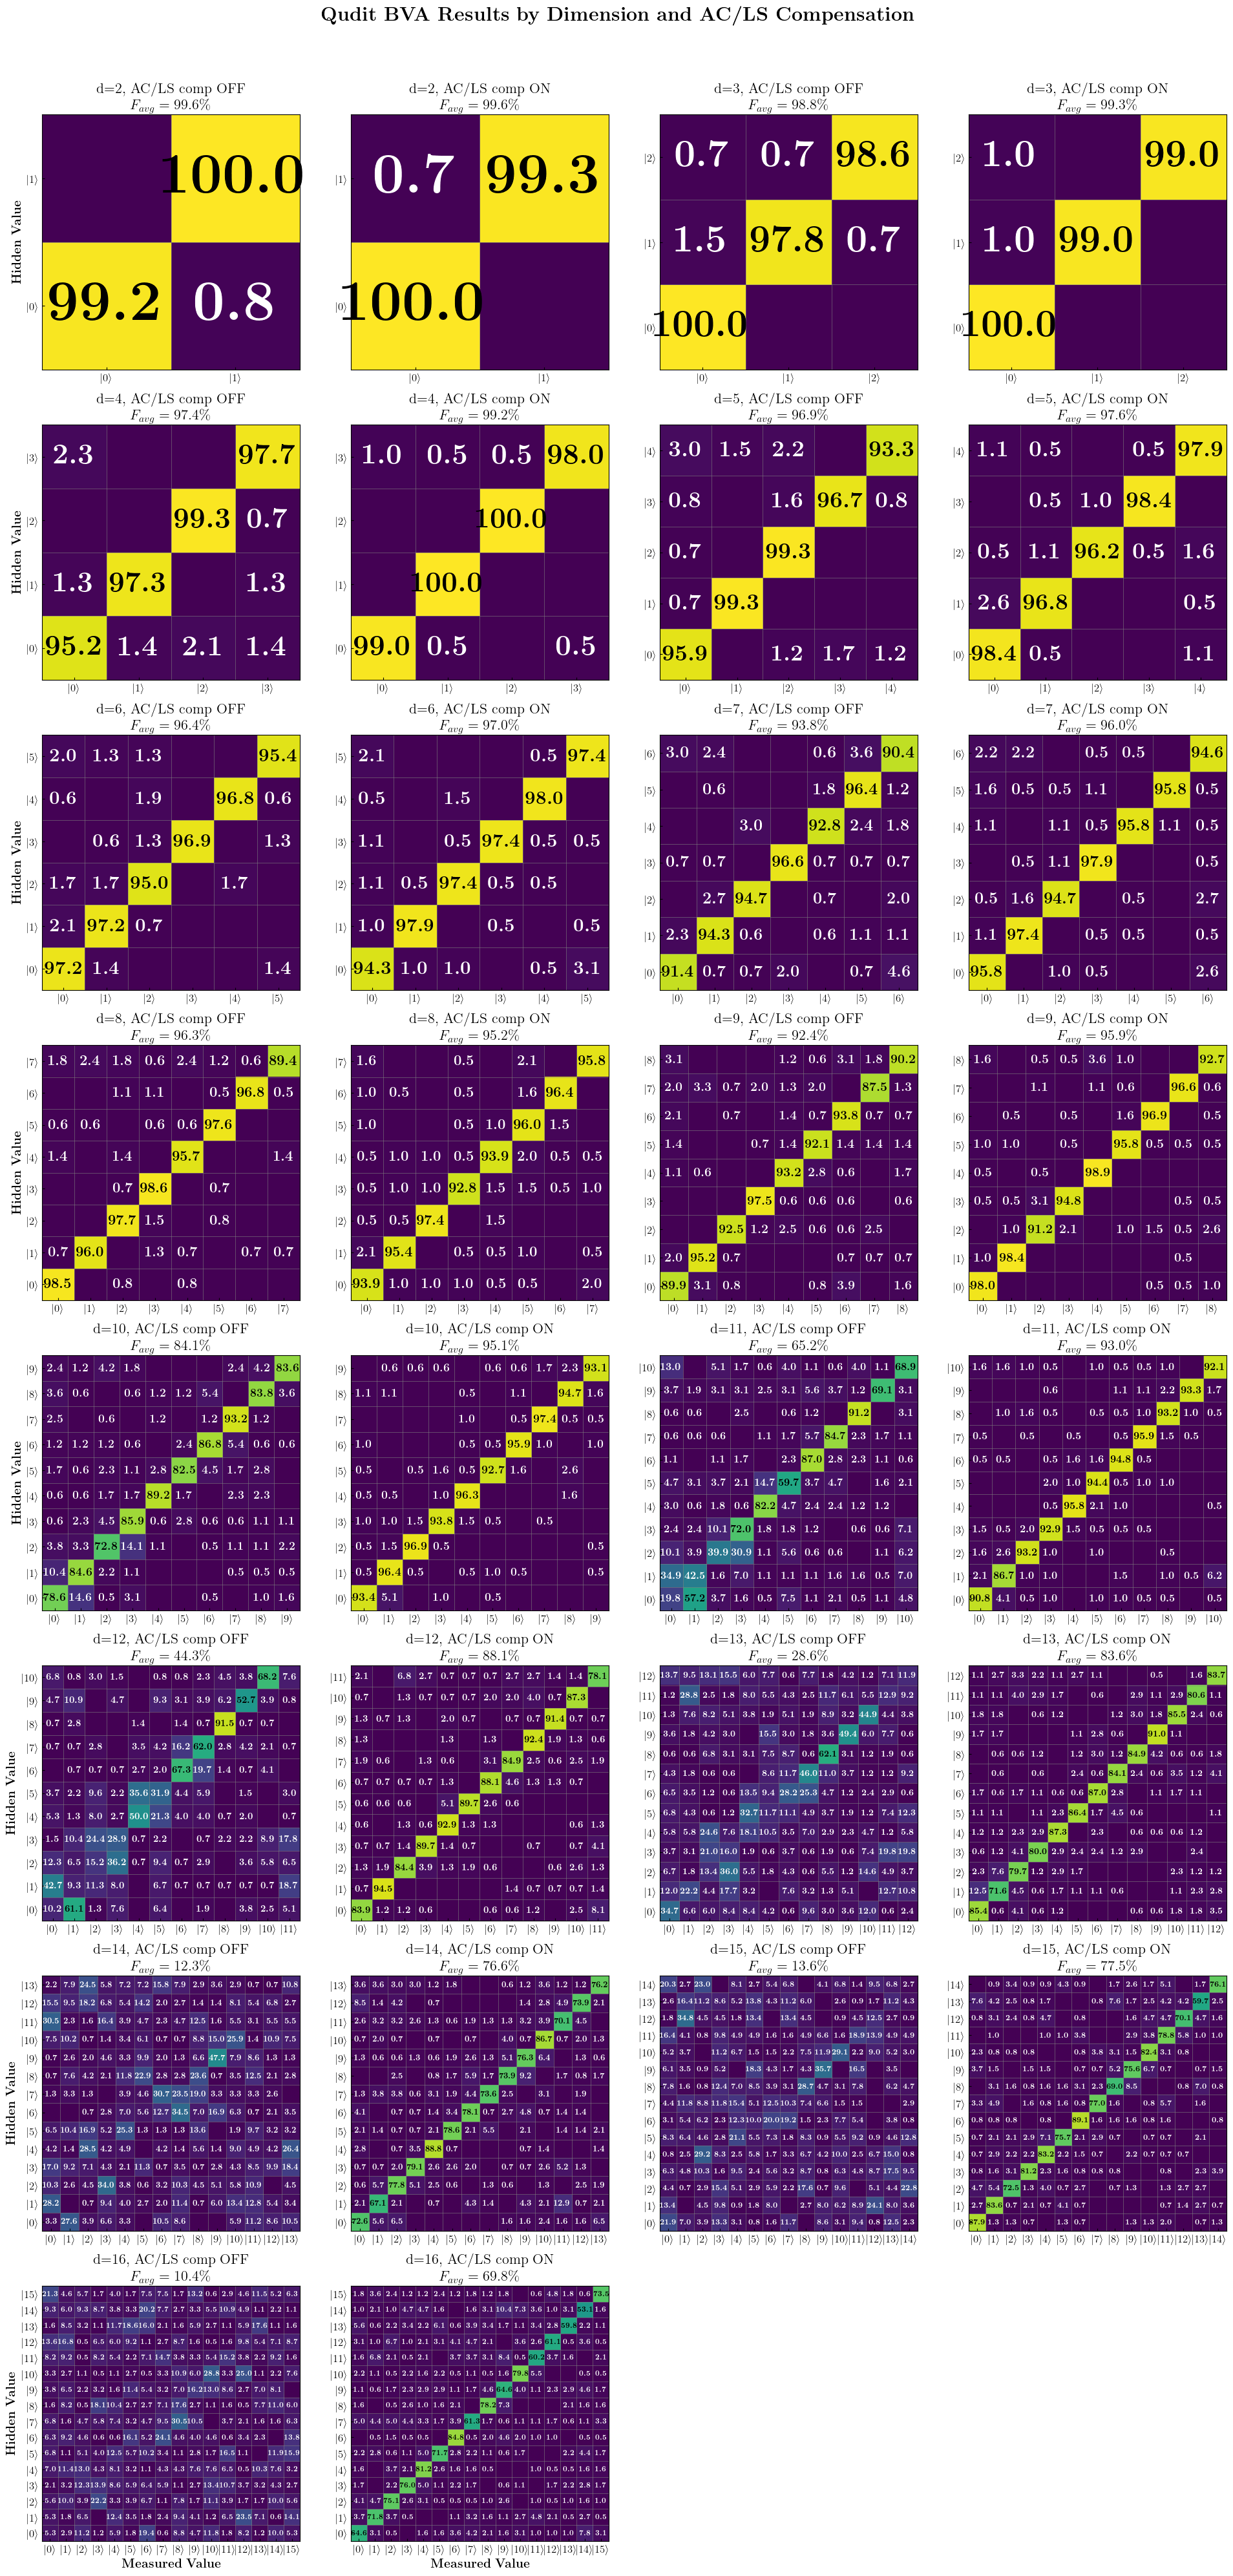

In [6]:
from math import ceil

# Heatmap grid for all analyzed dimensions.
# Layout: 4 columns total, arranged as
# [d1 False, d1 True, d2 False, d2 True] on each row.

result_lookup = {False: {}, True: {}}
for lt_value in [False, True]:
    for result in batch_results[lt_value]:
        result_lookup[lt_value][result['dimension']] = result

all_dimensions = sorted(set(dimensions_by_lt[False]) | set(dimensions_by_lt[True]))
if len(all_dimensions) == 0:
    raise ValueError('No batch analysis results are available to plot.')

pairs_per_row = 2
n_rows = ceil(len(all_dimensions) / pairs_per_row)
n_cols = 4

available_matrices = [
    np.asarray(result_lookup[lt_value][dim_value]['data_m'], dtype=float)
    for dim_value in all_dimensions
    for lt_value in [False, True]
    if dim_value in result_lookup[lt_value]
]
vmax = max(np.max(matrix) for matrix in available_matrices) if available_matrices else 1.0
vmax = max(float(vmax), 1e-6)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.8 * n_cols, max(4.5, 5.0 * n_rows)),
    squeeze=False,
)

for ax in axes.ravel():
    ax.axis('off')

for dim_index, dim_value in enumerate(all_dimensions):
    row = dim_index // pairs_per_row
    pair_offset = dim_index % pairs_per_row
    base_col = 2 * pair_offset

    for lt_offset, lt_value in enumerate([False, True]):
        ax = axes[row, base_col + lt_offset]
        ax.axis('on')

        result = result_lookup[lt_value].get(dim_value)
        lt_label = 'AC/LS comp ON' if lt_value else 'AC/LS comp OFF'

        if result is None:
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f'd={dim_value}, {lt_label}', fontsize=16)
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=18, color='red', transform=ax.transAxes)
            continue

        data_m = np.asarray(result['data_m'], dtype=float)
        im = ax.imshow(data_m, cmap='viridis', aspect='auto', vmin=0.0, vmax=vmax)

        hidden_values = result['hidden_values']
        measured_dim = data_m.shape[1]
        hidden_labels = [rf'$|{value}\rangle$' for value in hidden_values]
        measured_labels = [rf'$|{value}\rangle$' for value in range(measured_dim)]

        ax.set_xticks(np.arange(measured_dim))
        ax.set_xticklabels(measured_labels, fontsize=12)
        ax.set_yticks(np.arange(len(hidden_values)))
        ax.set_yticklabels(hidden_labels, fontsize=12)
        ax.invert_yaxis()
        ax.set_title(
            f'd={dim_value}, {lt_label}\n' + rf'$F_{{avg}} = {100.0 * result["avg_success_probability"]:.1f}\%$',
            fontsize=16,
        )

        if base_col == 0 and lt_offset == 0:
            ax.set_ylabel(r'\textbf{Hidden Value}', fontsize=14)
        else:
            ax.set_ylabel('')

        if row == n_rows - 1:
            ax.set_xlabel(r'\textbf{Measured Value}', fontsize=14)

        for x in np.arange(-0.5, measured_dim, 1):
            ax.axvline(x, color='gray', linewidth=0.4)
        for y in np.arange(-0.5, len(hidden_values), 1):
            ax.axhline(y, color='gray', linewidth=0.4)

        for row_index in range(data_m.shape[0]):
            for col_index in range(data_m.shape[1]):
                value = data_m[row_index, col_index]
                if value <= 0.005:
                    continue
                ax.text(
                    col_index,
                    row_index,
                    rf'\textbf{{{100.0 * value:.1f}}}',
                    ha='center',
                    va='center',
                    color='black' if value > 0.5 else 'white',
                    fontsize=128/dim_value,
                    fontweight='bold',
                )

for row in range(n_rows):
    for col in range(n_cols):
        if not axes[row, col].has_data() and len(axes[row, col].texts) == 0:
            axes[row, col].axis('off')

fig.suptitle(r'\textbf{Qudit BVA Results by Dimension and AC/LS Compensation}', fontsize=22, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


# Simulation and Data together

In [7]:
import io
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.special import voigt_profile
from matplotlib import rcParams

if 'batch_results' not in globals():
    raise RuntimeError("Run the batch-dimension-analysis cell before running this simulation overlay cell.")

module_dir = Path(r"C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\BVA_analysis_scripts")
if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))

from Functions_Algorithms import compile_algorithm_pulses

np.set_printoptions(precision=4, suppress=True)

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True

def basis_state(index: int, d: int) -> np.ndarray:
    """
    Return |index> in dimension d.
    """
    if not (0 <= index < d):
        raise ValueError("index must be in {0, ..., d-1}")

    state = np.zeros(d, dtype=complex)
    state[index] = 1.0
    return state

def wrap_pi(x):
    return (x + np.pi) % (2 * np.pi) - np.pi


def wrap_frame(z_frame):
    z = np.asarray(z_frame, dtype=float)
    return np.array([wrap_pi(value) for value in z], dtype=float)


def relative_frame(z_frame, reference=0):
    z = wrap_frame(z_frame)
    return wrap_frame(z - z[reference])

def virtual_z_diagonal(z_frame):
    return np.diag(np.exp(1j * np.asarray(z_frame, dtype=float)))


def sequence_target_unitary(unitaries):
    total = np.eye(unitaries[0].shape[0], dtype=complex)
    for U in unitaries:
        total = U @ total
    return total

def ion_pulse_unitary(coupling, theta, phi, dim):
    i, j = coupling
    U = np.eye(dim, dtype=complex)
    c = np.cos(theta / 2)
    s = np.sin(theta / 2)
    U[i, i] = c
    U[j, j] = c
    U[i, j] = -1j * np.exp(1j * phi) * s
    U[j, i] = -1j * np.exp(-1j * phi) * s
    return U

def pulse_sequence_unitary(schedule, dim):
    U = np.eye(dim, dtype=complex)
    for step in schedule:
        U = ion_pulse_unitary(step["coupling"], step["theta"], step["phi_programmed"], dim) @ U
    return U

simulation_mappings = {
    0: '0',
    1: '[4, -2]',
    2: '[3, 1]',
    3: '[4, -1]',
    4: '[3, 0]',
    5: '[3, 2]',
    6: '[4, 0]',
    7: '[2, -2]',
    8: '[2, 0]',
    9: '[2, 2]',
    10: '[4, 1]',
    11: '[3, -1]',
    12: '[1, 1]',
    13: '[2, -1]',
    14: '[1, -1]',
    15: '[2, 1]',
}

# center = 0
# tol = 1e-10
# minimize_gamma = False
# initial_frame = None
# initial_state_index = 0

# transition_strengths_file = r'Z:\Lab Data\Phase_and_freq_correction_180Hz\Transition_strengths_4p209.txt'
# sensitivity_matrix_file = r'Z:\Lab Data\Phase_and_freq_correction_180Hz\sensitivities_4p2079.txt'
# line_signal_param_file = r'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt'

# reference_pi_times_us = np.array([23.9, 25.491, 98.8, 25.836, 32.11], dtype=float)
# reference_strength_indices = [(21, 2), (14, 0), (5, 2), (16, 4), (15, 4)]

center = 0
tol = 1e-10
minimize_gamma = False
initial_frame = None
initial_state_index = 0
use_short_U1 = True

transition_strengths_file = r'Z:\Lab Data\Phase_and_freq_correction_180Hz\Transition_strengths_4p209.txt'
sensitivity_matrix_file = r'Z:\Lab Data\Phase_and_freq_correction_180Hz\sensitivities_4p2079.txt'
line_signal_param_file = r'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params_20260220.txt'

reference_pi_times_us = np.array([23.9, 25.491, 98.8, 25.836, 32.11], dtype=float)
reference_strength_indices = [(21, 2), (14, 0), (5, 2), (16, 4), (15, 4)]

def parse_string_to_int_list(s):
    s = str(s).strip()
    if s.startswith('[') and s.endswith(']'):
        inside = s[1:-1].strip()
        if not inside:
            return []
        return [int(value.strip()) for value in inside.split(',')]
    return [int(s)]


def build_transitions_list(index_to_str_map, couplings):
    missing = sorted({index for coupling in couplings for index in coupling if index not in index_to_str_map})
    if missing:
        raise KeyError(f'mappings is missing indices: {missing}')
    transitions_list = []
    for start_idx, end_idx in couplings:
        left_list = parse_string_to_int_list(index_to_str_map[start_idx])
        right_list = parse_string_to_int_list(index_to_str_map[end_idx])
        transitions_list.append(left_list + right_list)
    return transitions_list


transition_strengths = np.loadtxt(transition_strengths_file, delimiter=',')
transition_strengths = np.asarray(transition_strengths, dtype=float)
transition_strengths[transition_strengths == 0] = np.nan
reference_strengths = np.array([transition_strengths[row, col] for row, col in reference_strength_indices], dtype=float)


def compute_pi_times(pi_t, ref_transitions=reference_strengths, strengths_matrix=transition_strengths):
    strengths_matrix = np.asarray(strengths_matrix, dtype=float)
    factors = np.asarray(pi_t, dtype=float) * np.asarray(ref_transitions, dtype=float)
    Fs = [1, 2, 3, 4]
    row_labels = [[i, i - j] for i in Fs for j in range(2 * i + 1)]
    col_labels = [-2, -1, 0, 1, 2]

    pi_times = np.zeros_like(strengths_matrix, dtype=float)
    for i in range(strengths_matrix.shape[0]):
        for j in range(strengths_matrix.shape[1]):
            if not np.isnan(strengths_matrix[i, j]):
                delta_m = (row_labels[i][1] - col_labels[j]) + 2
                pi_times[i, j] = factors[delta_m] / strengths_matrix[i, j]
            else:
                pi_times[i, j] = np.nan
    return pi_times


def get_pi_times(transitions, pi_t=reference_pi_times_us, ref_transitions=reference_strengths):
    matrix = compute_pi_times(pi_t, ref_transitions)
    pi_times_list = []
    col_labels = [-2, -1, 0, 1, 2]
    states = [[i, i - j] for i in [1, 2, 3, 4] for j in range(2 * i + 1)]
    for transition in transitions:
        if len(transition) >= 3 and transition[1] == 0 and transition[2] == 0:
            pi_times_list.append(1e6)
            continue
        row_label = [transition[1], transition[2]]
        col_label = transition[0]
        row_index = next((idx for idx, label in enumerate(states) if label == row_label), None)
        col_index = col_labels.index(col_label) if col_label in col_labels else None
        if row_index is not None and col_index is not None:
            pi_times_list.append(matrix[row_index, col_index])
        else:
            pi_times_list.append(1e6)
    return pi_times_list


sens_matrix = np.loadtxt(sensitivity_matrix_file, delimiter=',')
sens_matrix = np.asarray(sens_matrix, dtype=float)


def get_values_from_matrix(transitions, matrix):
    row_labels = [[i, i - j] for i in [1, 2, 3, 4] for j in range(2 * i + 1)]
    col_labels = [-2, -1, 0, 1, 2]
    out = []
    for transition in transitions:
        row_label = [transition[1], transition[2]]
        col_label = transition[0]
        row_index = next((idx for idx, label in enumerate(row_labels) if label == row_label), None)
        col_index = col_labels.index(col_label) if col_label in col_labels else None
        if row_index is not None and col_index is not None:
            out.append(matrix[row_index, col_index])
        else:
            out.append(np.nan)
    return out

import matplotlib.pyplot as plt
from scipy.linalg import expm
from matplotlib import rcParams
import json

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True



def state_populations(state):
    state = np.asarray(state, dtype=complex)
    return np.abs(state) ** 2


def coupling_key(coupling):
    return tuple(int(value) for value in coupling)


def resolve_pi_times_us(couplings, default_pi_time_us, pi_time_by_coupling_us=None, per_pulse_pi_time_us=None):
    couplings = [coupling_key(coupling) for coupling in couplings]
    if per_pulse_pi_time_us is not None:
        pi_times_us = np.asarray(per_pulse_pi_time_us, dtype=float)
        if pi_times_us.shape != (len(couplings),):
            raise ValueError("per_pulse_pi_time_us must have length equal to the pulse count")
        return pi_times_us
    default_pi_time_us = float(default_pi_time_us)
    pi_time_by_coupling_us = {} if pi_time_by_coupling_us is None else {
        coupling_key(key): float(value) for key, value in pi_time_by_coupling_us.items()
    }
    return np.asarray([pi_time_by_coupling_us.get(coupling, default_pi_time_us) for coupling in couplings], dtype=float)


def pulse_durations_us_from_thetas(thetas, pi_times_us):
    thetas = np.asarray(thetas, dtype=float)
    pi_times_us = np.asarray(pi_times_us, dtype=float)
    if thetas.shape != pi_times_us.shape:
        raise ValueError("thetas and pi_times_us must have the same shape")
    return thetas * pi_times_us / np.pi


def pulse_timing_us(durations_us):
    durations_us = np.asarray(durations_us, dtype=float)
    t_end = np.cumsum(durations_us)
    t_start = np.concatenate(([0.0], t_end[:-1])) if len(durations_us) else np.asarray([], dtype=float)
    return np.column_stack((t_start, t_end)) if len(durations_us) else np.empty((0, 2), dtype=float)


def default_line_noise_model():
    return {"B0_mG": 0.2289, "harmonics": [(60.0, -0.2791, 1.0002), (180.0, -0.0774, -0.2650)]}


def _line_model_arrays(line_model):
    if line_model is None:
        line_model = default_line_noise_model()
    harmonics = line_model.get("harmonics", [])
    freqs_hz = np.asarray([item[0] for item in harmonics], dtype=float)
    amplitudes_mG = np.asarray([item[1] for item in harmonics], dtype=float)
    phases_rad = np.asarray([item[2] for item in harmonics], dtype=float)
    return float(line_model.get("B0_mG", 0.0)), freqs_hz, amplitudes_mG, phases_rad


def line_field_relative_G(t_sec, line_model=None):
    t_sec = np.asarray(t_sec, dtype=float)
    B0_mG, freqs_hz, amplitudes_mG, phases_rad = _line_model_arrays(line_model)
    field_mG = np.full_like(t_sec, B0_mG, dtype=float)
    reference_mG = B0_mG
    for freq_hz, amplitude_mG, phase_rad in zip(freqs_hz, amplitudes_mG, phases_rad):
        field_mG += amplitude_mG * np.cos(2.0 * np.pi * freq_hz * t_sec + phase_rad)
        reference_mG += amplitude_mG * np.cos(phase_rad)
    return (field_mG - reference_mG) * 1e-3


def line_field_primitive_Gs(t_sec, line_model=None):
    t_sec = np.asarray(t_sec, dtype=float)
    B0_mG, freqs_hz, amplitudes_mG, phases_rad = _line_model_arrays(line_model)
    reference_mG = B0_mG + np.sum(amplitudes_mG * np.cos(phases_rad))
    primitive_mGs = (B0_mG - reference_mG) * t_sec
    for freq_hz, amplitude_mG, phase_rad in zip(freqs_hz, amplitudes_mG, phases_rad):
        omega = 2.0 * np.pi * freq_hz
        primitive_mGs += (amplitude_mG / omega) * (np.sin(omega * t_sec + phase_rad) - np.sin(phase_rad))
    return primitive_mGs * 1e-3


def compute_line_phase_corrections(durations_us, sensitivities_mhz_per_g, line_model=None, t_ref="start", enabled=True):
    durations_us = np.asarray(durations_us, dtype=float)
    sensitivities_mhz_per_g = np.asarray(sensitivities_mhz_per_g, dtype=float)
    if durations_us.shape != sensitivities_mhz_per_g.shape:
        raise ValueError("durations_us and sensitivities_mhz_per_g must have the same shape")
    if not enabled or len(durations_us) == 0:
        zeros = np.zeros(len(durations_us), dtype=float)
        return zeros, zeros, zeros
    timing_us = pulse_timing_us(durations_us)
    pulse_starts_sec = timing_us[:, 0] * 1e-6
    pulse_ends_sec = timing_us[:, 1] * 1e-6
    if t_ref == "start":
        t_refs_sec = pulse_starts_sec
    elif t_ref == "end":
        t_refs_sec = pulse_ends_sec
    elif t_ref == "mid":
        t_refs_sec = 0.5 * (pulse_starts_sec + pulse_ends_sec)
    else:
        raise ValueError("t_ref must be one of 'start', 'mid', or 'end'")
    area_Gs = -line_field_primitive_Gs(t_refs_sec, line_model=line_model)
    B_rel_G = line_field_relative_G(t_refs_sec, line_model=line_model)
    phases_rad = 2.0 * np.pi * 1e6 * sensitivities_mhz_per_g * area_Gs
    detunings_mhz = B_rel_G * sensitivities_mhz_per_g
    return phases_rad, detunings_mhz, t_refs_sec

from functools import lru_cache
from scipy.special import voigt_profile


def laser_noise_widths_hz(gaussian_T_s, lorentzian_L_s):
    sigma_hz = np.sqrt(2.0) / float(gaussian_T_s)
    gamma_hz = 1.0 / float(lorentzian_L_s)
    return sigma_hz, gamma_hz


@lru_cache(maxsize=None)
def _cached_voigt_cdf_grid(sigma_hz, gamma_hz, x_min_hz, x_max_hz, num_points):
    sigma_hz = float(sigma_hz)
    gamma_hz = float(gamma_hz)
    x_min_hz = float(x_min_hz)
    x_max_hz = float(x_max_hz)
    num_points = int(num_points)
    if num_points < 2:
        raise ValueError('num_points must be at least 2')
    if not x_min_hz < x_max_hz:
        raise ValueError('x_min_hz must be less than x_max_hz')

    x_vals = np.linspace(x_min_hz, x_max_hz, num_points, dtype=float)
    dx = x_vals[1] - x_vals[0]
    profile_vals = voigt_profile(x_vals, sigma_hz, gamma_hz)
    cdf = np.cumsum(profile_vals) * dx
    if not np.isfinite(cdf[-1]) or cdf[-1] <= 0.0:
        raise ValueError('Voigt CDF normalization failed; check sigma/gamma and sampling window')
    cdf /= cdf[-1]
    cdf = np.maximum.accumulate(cdf)
    cdf[-1] = 1.0
    return x_vals, cdf


def sample_voigt_hz(rng=None, sigma_hz=0.0, gamma_hz=0.0, size=None, x_min_hz=-1000.0, x_max_hz=1000.0, num_points=100000):
    generator = np.random.default_rng() if rng is None else rng
    sigma_hz = max(float(sigma_hz), 0.0)
    gamma_hz = max(float(gamma_hz), 0.0)
    if sigma_hz == 0.0 and gamma_hz == 0.0:
        if size is None:
            return 0.0
        return np.zeros(size, dtype=float)

    x_vals, cdf = _cached_voigt_cdf_grid(sigma_hz, gamma_hz, float(x_min_hz), float(x_max_hz), int(num_points))
    u = generator.random(size=size)
    samples = np.interp(u, cdf, x_vals)
    if size is None:
        return float(samples)
    return samples


def sample_frequency_calibration_error_hz(rng=None, sigma_hz=0.0, hwhm_hz=14.976, size=None, x_min_hz=-1000.0, x_max_hz=1000.0, num_points=100000):
    return sample_voigt_hz(
        rng=rng,
        sigma_hz=sigma_hz,
        gamma_hz=float(hwhm_hz),
        size=size,
        x_min_hz=x_min_hz,
        x_max_hz=x_max_hz,
        num_points=num_points,
    )


def sample_laser_noise_hz(rng=None, gaussian_T_s=2 * np.pi * 1521.1210128727998e-6, lorentzian_L_s=2 * np.pi * 3038.1329363025798e-6, x_min_hz=-1000.0, x_max_hz=1000.0, num_points=100000):
    sigma_hz, gamma_hz = laser_noise_widths_hz(gaussian_T_s, lorentzian_L_s)
    return sample_voigt_hz(
        rng=rng,
        sigma_hz=sigma_hz,
        gamma_hz=gamma_hz,
        size=None,
        x_min_hz=x_min_hz,
        x_max_hz=x_max_hz,
        num_points=num_points,
    )


def sample_rabi_frequency_scale(rng=None, std_fraction=0.037):
    generator = np.random.default_rng() if rng is None else rng
    return 1.0 + float(std_fraction) * generator.normal()


def sample_line_signal_field_offset_g(rng=None, std_g=50e-6):
    generator = np.random.default_rng() if rng is None else rng
    return float(std_g) * generator.normal()


def line_signal_field_noise_corrections(durations_us, sensitivities_mhz_per_g, line_field_offset_g=0.0, t_ref="start"):
    durations_us = np.asarray(durations_us, dtype=float)
    sensitivities_mhz_per_g = np.asarray(sensitivities_mhz_per_g, dtype=float)
    if durations_us.shape != sensitivities_mhz_per_g.shape:
        raise ValueError("durations_us and sensitivities_mhz_per_g must have the same shape")
    if len(durations_us) == 0 or float(line_field_offset_g) == 0.0:
        zeros = np.zeros(len(durations_us), dtype=float)
        return zeros, zeros, zeros

    timing_us = pulse_timing_us(durations_us)
    pulse_starts_sec = timing_us[:, 0] * 1e-6
    pulse_ends_sec = timing_us[:, 1] * 1e-6
    if t_ref == "start":
        t_refs_sec = pulse_starts_sec
    elif t_ref == "end":
        t_refs_sec = pulse_ends_sec
    elif t_ref == "mid":
        t_refs_sec = 0.5 * (pulse_starts_sec + pulse_ends_sec)
    else:
        raise ValueError("t_ref must be one of 'start', 'mid', or 'end'")

    area_Gs = float(line_field_offset_g) * t_refs_sec
    phases_rad = 2.0 * np.pi * 1e6 * sensitivities_mhz_per_g * area_Gs
    detunings_mhz = float(line_field_offset_g) * sensitivities_mhz_per_g
    return phases_rad, detunings_mhz, t_refs_sec


def build_unique_coupling_noise_inputs(couplings, pulse_sensitivities_mhz_per_g, atol=1e-12):
    couplings = [coupling_key(coupling) for coupling in couplings]
    pulse_sensitivities_mhz_per_g = np.asarray(pulse_sensitivities_mhz_per_g, dtype=float)
    if pulse_sensitivities_mhz_per_g.shape != (len(couplings),):
        raise ValueError("pulse_sensitivities_mhz_per_g must have length equal to the pulse count")
    unique_couplings, unique_sensitivities, inverse_indices, index_lookup = [], [], [], {}
    for coupling, sensitivity in zip(couplings, pulse_sensitivities_mhz_per_g):
        if coupling not in index_lookup:
            index_lookup[coupling] = len(unique_couplings)
            unique_couplings.append(coupling)
            unique_sensitivities.append(float(sensitivity))
        else:
            existing_index = index_lookup[coupling]
            if not np.isclose(unique_sensitivities[existing_index], float(sensitivity), atol=atol, rtol=0.0):
                raise ValueError(
                    f"Coupling {coupling} appears with multiple sensitivity values: "
                    f"{unique_sensitivities[existing_index]} and {float(sensitivity)}"
                )
        inverse_indices.append(index_lookup[coupling])
    return {"couplings": unique_couplings, "sensitivities_mhz_per_g": np.asarray(unique_sensitivities, dtype=float), "inverse_indices": np.asarray(inverse_indices, dtype=int)}


def sample_unique_coupling_detunings_mhz(unique_sensitivities_mhz_per_g, rng=None, calibration_scale=1.0, magnetic_scale=1.0, laser_scale=1.0, calibration_noise_hwhm_hz=14.976, calibration_noise_sigma_hz=0.0, magnetic_field_std_g=11.13e-6, gaussian_T_s=2 * np.pi * 1521.1210128727998e-6, lorentzian_L_s=2 * np.pi * 8391.117123441047e-6, voigt_x_min_hz=-1000.0, voigt_x_max_hz=1000.0, voigt_num_points=100000):
    generator = np.random.default_rng() if rng is None else rng
    unique_sensitivities_mhz_per_g = np.asarray(unique_sensitivities_mhz_per_g, dtype=float)
    num_couplings = len(unique_sensitivities_mhz_per_g)

    shared_calibration_noise_hz = calibration_scale * sample_frequency_calibration_error_hz(
        generator,
        sigma_hz=calibration_noise_sigma_hz,
        hwhm_hz=calibration_noise_hwhm_hz,
        size=None,
        x_min_hz=voigt_x_min_hz,
        x_max_hz=voigt_x_max_hz,
        num_points=voigt_num_points,
    )
    calibration_noise_mhz = np.full(num_couplings, shared_calibration_noise_hz * 1e-6, dtype=float)

    magnetic_field_sample_g = magnetic_scale * generator.normal(0.0, magnetic_field_std_g)
    magnetic_noise_mhz = magnetic_field_sample_g * unique_sensitivities_mhz_per_g

    shared_laser_noise_hz = laser_scale * sample_laser_noise_hz(
        generator,
        gaussian_T_s=gaussian_T_s,
        lorentzian_L_s=lorentzian_L_s,
        x_min_hz=voigt_x_min_hz,
        x_max_hz=voigt_x_max_hz,
        num_points=voigt_num_points,
    )
    laser_noise_mhz = np.full(num_couplings, shared_laser_noise_hz * 1e-6, dtype=float)
    return calibration_noise_mhz + magnetic_noise_mhz + laser_noise_mhz


def simulate_schedule_state(couplings, durations_us, thetas, programmed_phases, initial_state, final_frame=None, apply_final_frame=False, line_phase_offsets_rad=None, line_detunings_mhz=None, global_detuning_mhz_by_coupling=None, rabi_frequency_scales=None):
    couplings = [coupling_key(coupling) for coupling in couplings]
    durations_us = np.asarray(durations_us, dtype=float)
    thetas = np.asarray(thetas, dtype=float)
    programmed_phases = np.asarray(programmed_phases, dtype=float)
    initial_state = np.asarray(initial_state, dtype=complex)
    num_pulses = len(couplings)
    if durations_us.shape != (num_pulses,) or thetas.shape != (num_pulses,) or programmed_phases.shape != (num_pulses,):
        raise ValueError("couplings, durations_us, thetas, and programmed_phases must all have the same length")
    line_phase_offsets_rad = np.zeros(num_pulses, dtype=float) if line_phase_offsets_rad is None else np.asarray(line_phase_offsets_rad, dtype=float)
    line_detunings_mhz = np.zeros(num_pulses, dtype=float) if line_detunings_mhz is None else np.asarray(line_detunings_mhz, dtype=float)
    rabi_frequency_scales = np.ones(num_pulses, dtype=float) if rabi_frequency_scales is None else np.asarray(rabi_frequency_scales, dtype=float)
    if line_phase_offsets_rad.shape != (num_pulses,) or line_detunings_mhz.shape != (num_pulses,) or rabi_frequency_scales.shape != (num_pulses,):
        raise ValueError("line-phase, line-detuning, and rabi-scale arrays must have length equal to the pulse count")
    dim = initial_state.shape[0]
    state = initial_state.copy()
    H_det_global = np.zeros((dim, dim), dtype=complex)
    if global_detuning_mhz_by_coupling is not None:
        for coupling, delta_mhz in global_detuning_mhz_by_coupling.items():
            i, j = coupling_key(coupling)
            delta_rad_per_us = 2.0 * np.pi * float(delta_mhz)
            H_det_global[i, i] += 0.5 * delta_rad_per_us
            H_det_global[j, j] -= 0.5 * delta_rad_per_us
    total_phases = programmed_phases + line_phase_offsets_rad
    for (i, j), duration_us, theta, total_phase, delta_line_mhz, rabi_scale in zip(couplings, durations_us, thetas, total_phases, line_detunings_mhz, rabi_frequency_scales):
        if duration_us <= 0.0:
            continue
        omega_rad_per_us = float(rabi_scale) * theta / duration_us
        H_pulse = H_det_global.copy()
        delta_line_rad_per_us = 2.0 * np.pi * float(delta_line_mhz)
        H_pulse[i, i] += 0.5 * delta_line_rad_per_us
        H_pulse[j, j] -= 0.5 * delta_line_rad_per_us
        phase_factor = np.exp(1j * total_phase)
        H_pulse[i, j] += 0.5 * omega_rad_per_us * phase_factor
        H_pulse[j, i] += 0.5 * omega_rad_per_us * np.conj(phase_factor)
        state = expm(-1j * H_pulse * duration_us) @ state
    if apply_final_frame and final_frame is not None:
        state = virtual_z_diagonal(final_frame) @ state
    return state


def monte_carlo_schedule(couplings, thetas, programmed_phases, initial_state, pulse_sensitivities_mhz_per_g, default_pi_time_us, pi_time_by_coupling_us=None, per_pulse_pi_time_us=None, final_frame=None, apply_final_frame=True, use_line_noise=False, line_model=None, line_reference="start", num_shots=100, rng_seed=None, calibration_scale=1.0, magnetic_scale=1.0, laser_scale=1.0, calibration_noise_hwhm_hz=14.976, calibration_noise_sigma_hz=0.0, magnetic_field_std_g=11.13e-6, laser_gaussian_T_s=2 * np.pi * 1521.1210128727998e-6, laser_lorentzian_L_s=2 * np.pi * 3038.1329363025798e-6, voigt_x_min_hz=-1000.0, voigt_x_max_hz=1000.0, voigt_num_points=100000, rabi_frequency_std_fraction=0.037, line_signal_noise_std_g=50e-6, target_state=None):
    couplings = [coupling_key(coupling) for coupling in couplings]
    thetas = np.asarray(thetas, dtype=float)
    programmed_phases = np.asarray(programmed_phases, dtype=float)
    pulse_sensitivities_mhz_per_g = np.asarray(pulse_sensitivities_mhz_per_g, dtype=float)
    initial_state = np.asarray(initial_state, dtype=complex)
    num_shots = int(num_shots)
    if num_shots < 1:
        raise ValueError("num_shots must be at least 1")
    pi_times_us = resolve_pi_times_us(couplings, default_pi_time_us=default_pi_time_us, pi_time_by_coupling_us=pi_time_by_coupling_us, per_pulse_pi_time_us=per_pulse_pi_time_us)
    durations_us = pulse_durations_us_from_thetas(thetas, pi_times_us)
    timing_us = pulse_timing_us(durations_us)
    base_line_phase_offsets_rad, base_line_detunings_mhz, line_reference_times_s = compute_line_phase_corrections(durations_us, pulse_sensitivities_mhz_per_g, line_model=line_model, t_ref=line_reference, enabled=use_line_noise)
    unique_noise_inputs = build_unique_coupling_noise_inputs(couplings, pulse_sensitivities_mhz_per_g)
    generator = np.random.default_rng(rng_seed)
    noiseless_state = simulate_schedule_state(couplings, durations_us, thetas, programmed_phases, initial_state=initial_state, final_frame=final_frame, apply_final_frame=apply_final_frame, line_phase_offsets_rad=base_line_phase_offsets_rad, line_detunings_mhz=base_line_detunings_mhz, global_detuning_mhz_by_coupling={coupling: 0.0 for coupling in unique_noise_inputs["couplings"]}, rabi_frequency_scales=np.ones(len(couplings), dtype=float))
    shot_populations, shot_fidelities = [], []
    for _ in range(num_shots):
        sampled_noise = sample_unique_coupling_detunings_mhz(
            unique_noise_inputs["sensitivities_mhz_per_g"],
            rng=generator,
            calibration_scale=calibration_scale,
            magnetic_scale=magnetic_scale,
            laser_scale=laser_scale,
            calibration_noise_hwhm_hz=calibration_noise_hwhm_hz,
            calibration_noise_sigma_hz=calibration_noise_sigma_hz,
            magnetic_field_std_g=magnetic_field_std_g,
            gaussian_T_s=laser_gaussian_T_s,
            lorentzian_L_s=laser_lorentzian_L_s,
            voigt_x_min_hz=voigt_x_min_hz,
            voigt_x_max_hz=voigt_x_max_hz,
            voigt_num_points=voigt_num_points,
        )
        detuning_map = {coupling: detuning_mhz for coupling, detuning_mhz in zip(unique_noise_inputs["couplings"], sampled_noise)}

        shared_rabi_scale = sample_rabi_frequency_scale(generator, std_fraction=rabi_frequency_std_fraction)
        rabi_frequency_scales = np.full(len(couplings), shared_rabi_scale, dtype=float)

        line_field_offset_g = sample_line_signal_field_offset_g(generator, std_g=line_signal_noise_std_g)
        line_noise_phases_rad, line_noise_detunings_mhz, _ = line_signal_field_noise_corrections(
            durations_us,
            pulse_sensitivities_mhz_per_g,
            line_field_offset_g=line_field_offset_g,
            t_ref=line_reference,
        )

        final_state = simulate_schedule_state(
            couplings,
            durations_us,
            thetas,
            programmed_phases,
            initial_state=initial_state,
            final_frame=final_frame,
            apply_final_frame=apply_final_frame,
            line_phase_offsets_rad=base_line_phase_offsets_rad + line_noise_phases_rad,
            line_detunings_mhz=base_line_detunings_mhz + line_noise_detunings_mhz,
            global_detuning_mhz_by_coupling=detuning_map,
            rabi_frequency_scales=rabi_frequency_scales,
        )
        shot_populations.append(state_populations(final_state))
        if target_state is not None:
            shot_fidelities.append(float(np.real_if_close(abs(np.vdot(target_state, final_state)) ** 2)))
    shot_populations = np.asarray(shot_populations, dtype=float)
    mean_populations = np.mean(shot_populations, axis=0)
    std_populations = np.std(shot_populations, axis=0, ddof=1) if num_shots > 1 else np.zeros_like(mean_populations)
    shot_fidelities = np.asarray(shot_fidelities, dtype=float)
    mean_fidelity = float(np.mean(shot_fidelities)) if len(shot_fidelities) else np.nan
    std_fidelity = float(np.std(shot_fidelities, ddof=1)) if len(shot_fidelities) > 1 else (0.0 if len(shot_fidelities) == 1 else np.nan)
    return {"pi_times_us": pi_times_us, "pulse_durations_us": durations_us, "timing_us": timing_us, "line_phase_offsets_rad": base_line_phase_offsets_rad, "line_detunings_mhz": base_line_detunings_mhz, "line_reference_times_s": line_reference_times_s, "noiseless_state": noiseless_state, "shot_populations": shot_populations, "mean_populations": mean_populations, "std_populations": std_populations, "shot_fidelities": shot_fidelities, "mean_fidelity": mean_fidelity, "std_fidelity": std_fidelity}

def basis_state(index: int, d: int) -> np.ndarray:
    """
    Return |index> in dimension d.
    """
    if not (0 <= index < d):
        raise ValueError("index must be in {0, ..., d-1}")

    state = np.zeros(d, dtype=complex)
    state[index] = 1.0
    return state


import io


def load_line_fit_parameters(filename):
    B0_fit = None
    B0_err = None
    harmonic_lines = []
    with open(filename, 'r') as f:
        for line in f:
            stripped = line.strip()
            if not stripped or stripped.startswith('#'):
                continue
            if B0_fit is None:
                vals = np.fromstring(stripped, sep=' ')
                B0_fit, B0_err = vals[0], vals[1]
            else:
                harmonic_lines.append(stripped)
    harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))
    if harmonics.ndim == 1:
        harmonics = harmonics[None, :]
    freqs = harmonics[:, 0]
    A_vals = harmonics[:, 1]
    A_errs = harmonics[:, 2]
    phi_vals = harmonics[:, 3]
    phi_errs = harmonics[:, 4]
    return B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs


def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
    if param_file is not None:
        B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
        return B0_fit, freqs, A_vals, phi_vals
    freqs = np.array([60.0, 180.0], dtype=float)
    A_vals = np.array([A60, A180], dtype=float)
    phi_vals = np.array([phi60, phi180], dtype=float)
    return B0, freqs, A_vals, phi_vals


def B_line_mG(t, B0, A60, phi60, A180, phi180, param_file=None):
    B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
    t_arr = np.asarray(t, dtype=float)
    y = np.full_like(t_arr, B0_use, dtype=float)
    for freq_hz, amplitude_mG, phase_rad in zip(freqs, A_vals, phi_vals):
        y = y + amplitude_mG * np.cos(2.0 * np.pi * freq_hz * t_arr + phase_rad)
    return y


def default_line_noise_model(param_file=r'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params_20260212.txt'):
    return {
        'B0_mG': 0.2289,
        'A60_mG': -0.2791,
        'phi60_rad': 1.0002,
        'A180_mG': -0.0774,
        'phi180_rad': -0.2650,
        'param_file': param_file,
    }


def _line_model_arrays(line_model):
    if line_model is None:
        line_model = default_line_noise_model()
    return _get_line_params(
        line_model.get('param_file'),
        line_model.get('B0_mG', 0.2289),
        line_model.get('A60_mG', -0.2791),
        line_model.get('phi60_rad', 1.0002),
        line_model.get('A180_mG', -0.0774),
        line_model.get('phi180_rad', -0.2650),
    )


def line_field_relative_G(t_sec, line_model=None):
    t_sec = np.asarray(t_sec, dtype=float)
    B0_use, freqs_hz, amplitudes_mG, phases_rad = _line_model_arrays(line_model)
    field_mG = np.full_like(t_sec, B0_use, dtype=float)
    reference_mG = B0_use
    for freq_hz, amplitude_mG, phase_rad in zip(freqs_hz, amplitudes_mG, phases_rad):
        field_mG += amplitude_mG * np.cos(2.0 * np.pi * freq_hz * t_sec + phase_rad)
        reference_mG += amplitude_mG * np.cos(phase_rad)
    return (field_mG - reference_mG) * 1e-3


def line_field_primitive_Gs(t_sec, line_model=None):
    t_sec = np.asarray(t_sec, dtype=float)
    B0_use, freqs_hz, amplitudes_mG, phases_rad = _line_model_arrays(line_model)
    B_line_0 = B0_use + np.sum(amplitudes_mG * np.cos(phases_rad))
    primitive_mGs = (B0_use - B_line_0) * t_sec
    for freq_hz, amplitude_mG, phase_rad in zip(freqs_hz, amplitudes_mG, phases_rad):
        omega = 2.0 * np.pi * freq_hz
        primitive_mGs += (amplitude_mG / omega) * (np.sin(omega * t_sec + phase_rad) - np.sin(phase_rad))
    return primitive_mGs * 1e-3


def compute_line_phase_corrections(durations_us, sensitivities_mhz_per_g, line_model=None, t_ref='start', enabled=True):
    durations_us = np.asarray(durations_us, dtype=float)
    sensitivities_mhz_per_g = np.asarray(sensitivities_mhz_per_g, dtype=float)
    if durations_us.shape != sensitivities_mhz_per_g.shape:
        raise ValueError('durations_us and sensitivities_mhz_per_g must have the same shape')
    if not enabled or len(durations_us) == 0:
        zeros = np.zeros(len(durations_us), dtype=float)
        return zeros, zeros, zeros

    timing_us = pulse_timing_us(durations_us)
    pulse_starts_sec = timing_us[:, 0] * 1e-6
    pulse_ends_sec = timing_us[:, 1] * 1e-6

    if t_ref == 'start':
        t_refs_sec = pulse_starts_sec
    elif t_ref == 'end':
        t_refs_sec = pulse_ends_sec
    elif t_ref == 'mid':
        t_refs_sec = 0.5 * (pulse_starts_sec + pulse_ends_sec)
    else:
        raise ValueError("t_ref must be one of 'start', 'mid', or 'end'")

    # pulse_interval_area_Gs = line_field_primitive_Gs(pulse_ends_sec, line_model=line_model) - line_field_primitive_Gs(pulse_starts_sec, line_model=line_model)
    pulse_interval_area_Gs = line_field_primitive_Gs(pulse_starts_sec, line_model=line_model)
    area_Gs = pulse_interval_area_Gs
    B_rel_G = line_field_relative_G(t_refs_sec, line_model=line_model)
    phases_rad = 2.0 * np.pi * 1e6 * sensitivities_mhz_per_g * area_Gs
    detunings_mhz = B_rel_G * sensitivities_mhz_per_g
    return phases_rad, detunings_mhz, t_refs_sec

use_line_noise = True
line_model = default_line_noise_model(param_file=line_signal_param_file)
line_reference = "start"

default_pi_time_us = 20.0
pi_time_by_coupling_us = {}
num_shots = 200
rng_seed = np.random.SeedSequence().entropy
calibration_scale = 1.0
magnetic_scale = 1.0
laser_scale = 1.0
calibration_noise_hwhm_hz = 15
calibration_noise_sigma_hz = 0.0
magnetic_field_std_g = 11.13e-6
laser_gaussian_T_s = 2*np.pi*2206.8675860990334e-6
laser_lorentzian_L_s = 2*np.pi*3353.155420102816e-6
voigt_x_min_hz = -1000.0
voigt_x_max_hz = 1000.0
voigt_num_points = 100000
rabi_frequency_std_fraction = 0.037
line_signal_noise_std_g = 0 * 50e-6
apply_final_frame = False

simulation_dimensions = list(range(2, 17))


def simulate_bva_average_success(dimensions_to_sweep, use_line_noise_override, use_short_U1_override, seed_offset=0):
    dimensions_sorted = sorted(int(dim_value) for dim_value in dimensions_to_sweep)
    avg_success = []
    std_success = []
    success_by_dimension = {}

    for dim_test in dimensions_sorted:
        if dim_test > len(simulation_mappings):
            raise ValueError(f"dimension {dim_test} exceeds the available simulation mapping size {len(simulation_mappings)}")

        dim_success_probabilities = []
        for hidden_value in range(dim_test):
            pulse_train_list_dim, pulse_angle_list_dim, pulse_phases_list_dim, compile_metadata_dim = compile_algorithm_pulses(
                simulation_mappings,
                dim_test,
                'BVA',
                center=center,
                tol=tol,
                minimize_gamma=minimize_gamma,
                initial_frame=initial_frame,
                return_metadata=True,
                use_short_U1=use_short_U1_override,
                hidden_value=hidden_value,
            )

            final_frame_dim = compile_metadata_dim['final_frame']
            couplings_dim = compile_metadata_dim['couplings']
            unitaries_dim = compile_metadata_dim['unitaries']
            thetas_dim = pulse_angle_list_dim
            phases_dim = pulse_phases_list_dim

            initial_state_dim = basis_state(initial_state_index, dim_test)
            target_state_dim = sequence_target_unitary(unitaries_dim) @ initial_state_dim
            if not use_line_noise_override:
                pulse_pi_times_dim = np.asarray(get_pi_times(pulse_train_list_dim), dtype=float)*0.8
            else:
                pulse_pi_times_dim = np.asarray(get_pi_times(pulse_train_list_dim), dtype=float)
            pulse_sensitivities_dim = np.asarray(
                get_values_from_matrix(pulse_train_list_dim, sens_matrix),
                dtype=float,
            )

            base_seed = rng_seed
            if base_seed is None:
                rng_seed_dim = None
            else:
                rng_seed_dim = int(base_seed) + int(seed_offset) + 1000 * dim_test + hidden_value

            simulation_result_dim = monte_carlo_schedule(
                couplings=couplings_dim,
                thetas=thetas_dim,
                programmed_phases=phases_dim,
                initial_state=initial_state_dim,
                pulse_sensitivities_mhz_per_g=pulse_sensitivities_dim,
                default_pi_time_us=default_pi_time_us,
                pi_time_by_coupling_us=pi_time_by_coupling_us,
                per_pulse_pi_time_us=pulse_pi_times_dim,
                final_frame=wrap_frame(final_frame_dim),
                apply_final_frame=apply_final_frame,
                use_line_noise=use_line_noise_override,
                line_model=line_model,
                line_reference=line_reference,
                num_shots=num_shots,
                rng_seed=rng_seed_dim,
                calibration_scale=calibration_scale,
                magnetic_scale=magnetic_scale,
                laser_scale=laser_scale,
                calibration_noise_hwhm_hz=calibration_noise_hwhm_hz,
                calibration_noise_sigma_hz=calibration_noise_sigma_hz,
                magnetic_field_std_g=magnetic_field_std_g,
                laser_gaussian_T_s=laser_gaussian_T_s,
                laser_lorentzian_L_s=laser_lorentzian_L_s,
                voigt_x_min_hz=voigt_x_min_hz,
                voigt_x_max_hz=voigt_x_max_hz,
                voigt_num_points=voigt_num_points,
                rabi_frequency_std_fraction=rabi_frequency_std_fraction,
                line_signal_noise_std_g=0 * line_signal_noise_std_g,
                target_state=target_state_dim,
            )

            dim_success_probabilities.append(simulation_result_dim['mean_populations'][hidden_value])

        dim_success_probabilities = np.asarray(dim_success_probabilities, dtype=float)
        success_by_dimension[dim_test] = dim_success_probabilities
        avg_success.append(np.mean(dim_success_probabilities))
        std_success.append(np.std(dim_success_probabilities, ddof=1) if len(dim_success_probabilities) > 1 else 0.0)

    return {
        'dimensions': dimensions_sorted,
        'avg_success_probability': np.asarray(avg_success, dtype=float),
        'std_success_probability': np.asarray(std_success, dtype=float),
        'success_by_dimension': success_by_dimension,
    }


simulation_overlay_results = {
    False: simulate_bva_average_success(
        simulation_dimensions,
        use_line_noise_override=True,
        use_short_U1_override=use_short_U1,
        seed_offset=0,
    ),
    True: simulate_bva_average_success(
        simulation_dimensions,
        use_line_noise_override=False,
        use_short_U1_override=use_short_U1,
        seed_offset=20000,
    ),
}

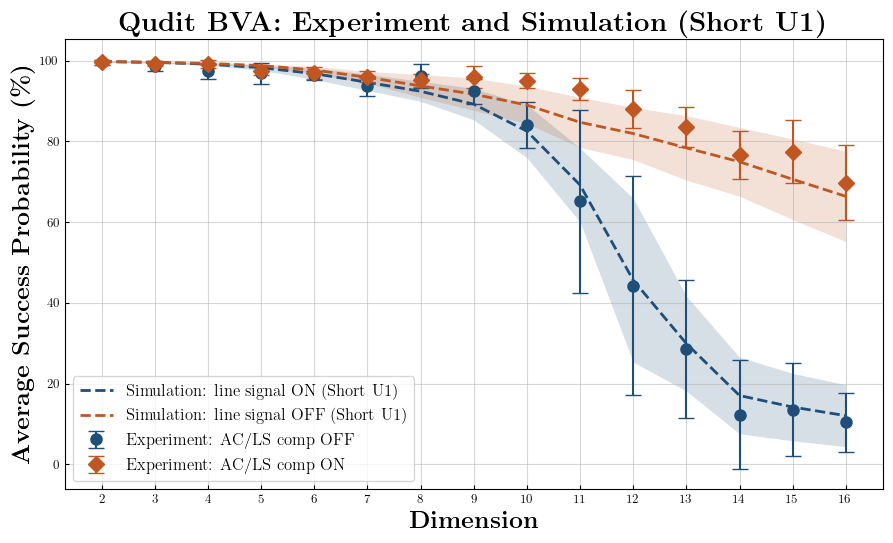

simulation overlay results:

LT_comp=False, simulated with line signal (Short U1)
  d= 2: simulated avg success =  99.79% , std across hidden values =   0.28%
  d= 3: simulated avg success =  99.59% , std across hidden values =   0.14%
  d= 4: simulated avg success =  99.16% , std across hidden values =   0.34%
  d= 5: simulated avg success =  98.28% , std across hidden values =   0.62%
  d= 6: simulated avg success =  96.81% , std across hidden values =   1.45%
  d= 7: simulated avg success =  94.66% , std across hidden values =   2.01%
  d= 8: simulated avg success =  92.43% , std across hidden values =   2.48%
  d= 9: simulated avg success =  89.25% , std across hidden values =   3.90%
  d=10: simulated avg success =  82.55% , std across hidden values =   6.56%
  d=11: simulated avg success =  69.21% , std across hidden values =   9.16%
  d=12: simulated avg success =  45.63% , std across hidden values =  20.29%
  d=13: simulated avg success =  29.93% , std across hidden values =  1

In [8]:
prep_mode_label = 'Short U1' if use_short_U1 else 'Full QFT'


fig, ax = plt.subplots(figsize=(9, 5.5))
plot_styles = {
    False: {
        'color': '#1f4e79',
        'marker': ['o', 'D', '^', 'v', 'P', '*', 'X', 'h', 'H', '8', 'p', '|', '_'],
        'actual_label': 'Experiment: AC/LS comp OFF',
        'sim_label': f'Simulation: line signal ON ({prep_mode_label})',
    },
    True: {
        'color': '#c05621',
        'marker': ['D', '^', 'v', 'P', '*', 'X', 'h', 'H', '8', 'p', '|', '_'],
        'actual_label': 'Experiment: AC/LS comp ON',
        'sim_label': f'Simulation: line signal OFF ({prep_mode_label})',
    },
}
print()
for lt_value in [False, True]:
    style = plot_styles[lt_value]

    dims_exp = dimensions_by_lt[lt_value]
    avg_exp = avg_success_probability_by_lt[lt_value]
    exp_err = experimental_error_by_lt[lt_value]
    if len(dims_exp) > 0:
        avg_exp_pct = 100.0 * np.asarray(avg_exp, dtype=float)
        exp_err_pct = 100.0 * np.asarray(exp_err, dtype=float)
        # ax.plot(
        #     dims_exp,
        #     avg_exp_pct,
        #     plot_styles[lt_value]['marker'][0],
        #     markersize=8,
        #     color=style['color'],
        #     label=style['actual_label'],
        # )

        ax.errorbar(
            dims_exp,
            avg_exp_pct,
            yerr = exp_err_pct,
            linestyle='',
            # linewidth=2.0,
            marker=style['marker'][0],
            markersize=8,
            capsize=6,
            color=style['color'],
            # ecolor=style['color'],
            label=style['actual_label'],
        )

        # ax.fill_between(
        #     dims_exp,
        #     avg_exp_pct - exp_err_pct,
        #     avg_exp_pct + exp_err_pct,
        #     color=style['color'],
        #     alpha=0.18,
        #     linewidth=0,
        # )

    dims_sim = simulation_overlay_results[lt_value]['dimensions']
    avg_sim = simulation_overlay_results[lt_value]['avg_success_probability']
    std_sim = simulation_overlay_results[lt_value]['std_success_probability']
    ax.plot(
        dims_sim,
        100.0 * avg_sim,
        # yerr=100.0 * std_sim,
        linestyle='--',
        linewidth=2.0,
        # marker=style['marker'][2],
        # markersize=6,
        # capsize=4,
        color=style['color'],
        # ecolor=style['color'],
        label=style['sim_label'],
    )

    ax.fill_between(
        dims_sim,
        100.0 * avg_sim - 100.0 * std_sim,
        100.0 * avg_sim + 100.0 * std_sim,
        color=style['color'],
        alpha=0.18,
        linewidth=0,
    )

ax.set_xlabel(r'\textbf{Dimension}', fontsize=18)
ax.set_ylabel(r'\textbf{Average Success Probability (\%)}', fontsize=18)
ax.set_title(rf'\textbf{{Qudit BVA: Experiment and Simulation ({prep_mode_label})}}', fontsize=20)
ax.set_xticks(simulation_dimensions)
ax.grid(True, alpha=0.5)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print('simulation overlay results:')
for lt_value in [False, True]:
    lt_label = (
        f'LT_comp=False, simulated with line signal ({prep_mode_label})'
        if not lt_value else
        f'LT_comp=True, simulated without line signal ({prep_mode_label})'
    )
    print(f"\n{lt_label}")
    dims_sim = simulation_overlay_results[lt_value]['dimensions']
    avg_sim = simulation_overlay_results[lt_value]['avg_success_probability']
    std_sim = simulation_overlay_results[lt_value]['std_success_probability']
    for dim_test, mean_success, std_success in zip(dims_sim, avg_sim, std_sim):
        print(
            f"  d={dim_test:2d}: simulated avg success = {100.0 * mean_success:6.2f}% , "
            f"std across hidden values = {100.0 * std_success:6.2f}%"
        )


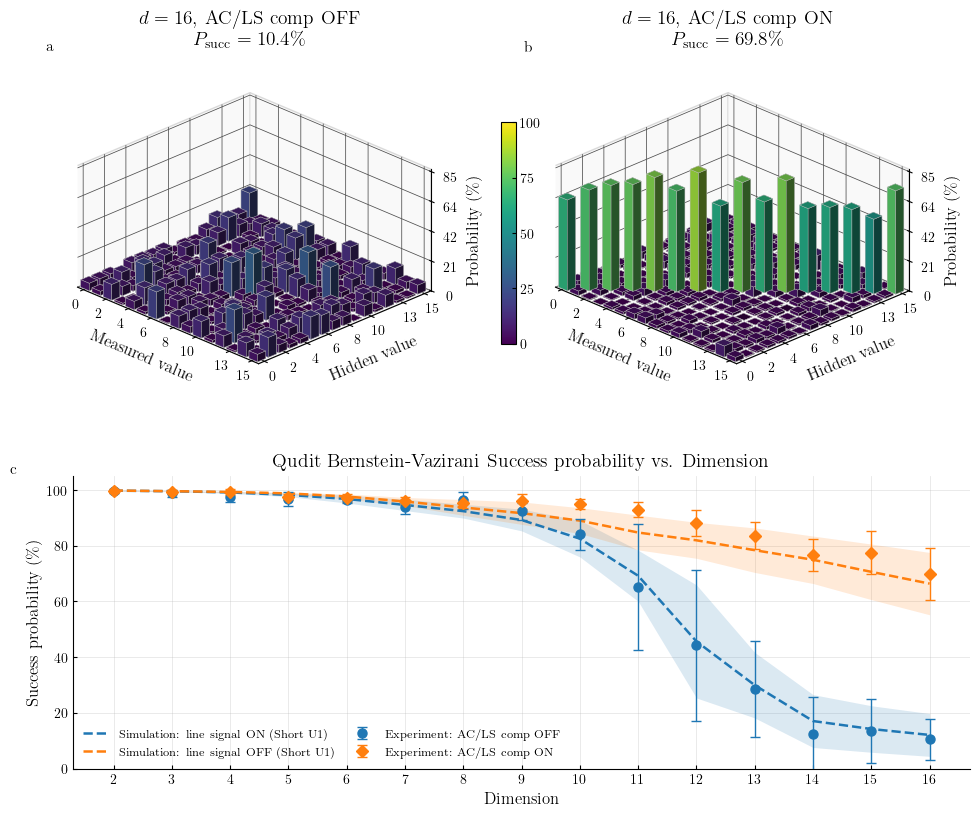

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# =========================================================
# STYLE
# =========================================================
rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# USER OPTIONS
# =========================================================
SAVE_FIGURE = True
OUTPUT_NAME = "BVA_summary_figure_3D.svg"

SHOW_TOP_COLORBAR = True
SHOW_BAR_VALUE_LABELS = False
MAX_TOP_TICK_LABELS = 7

# 3D camera angle
TOP_VIEW_ELEV = 25
TOP_VIEW_AZIM = -45

# Move top 3D plots.
# Negative x moves left, positive x moves right.
# Positive y moves up, negative y moves down.
TOP_3D_COMMON_SHIFT_X = 0.00
TOP_3D_COMMON_SHIFT_Y = 0.00

LEFT_3D_SHIFT_X = -0.025
LEFT_3D_SHIFT_Y = 0.00

RIGHT_3D_SHIFT_X = -0.04
RIGHT_3D_SHIFT_Y = 0.00

# Optional resizing of top 3D plots.
# 1.00 keeps original size.
LEFT_3D_SCALE = 1.00
RIGHT_3D_SCALE = 1.00

# Label/tick spacing
X_LABEL_PAD = 0
Y_LABEL_PAD = 0
Z_LABEL_PAD = -5      # smaller / more negative brings z-axis label closer

X_TICK_PAD = -2
Y_TICK_PAD = -2
Z_TICK_PAD = -1

# Shared font sizes
TITLE_FONTSIZE = 14
AXIS_LABEL_FONTSIZE = 12
TICK_FONTSIZE = 10
LEGEND_FONTSIZE = 8.5
PANEL_LABEL_FONTSIZE = 11

# Colorbar fixed from 0 to 100%.
# The 3D z-axis is matched to the actual max of the two top datasets.
COLORBAR_MIN = 0.0
COLORBAR_MAX = 1.0

prep_mode_label = 'Short U1' if use_short_U1 else 'Full QFT'

plot_styles = {
    False: {
        'color': 'C0',
        'marker': 'o',
        'panel_label': 'AC/LS comp OFF',
        'exp_label': 'Experiment: AC/LS comp OFF',
        'sim_label': f'Simulation: line signal ON ({prep_mode_label})',
    },
    True: {
        'color': 'C1',
        'marker': 'D',
        'panel_label': 'AC/LS comp ON',
        'exp_label': 'Experiment: AC/LS comp ON',
        'sim_label': f'Simulation: line signal OFF ({prep_mode_label})',
    },
}

# =========================================================
# LOOKUP TABLE
# =========================================================
result_lookup = {False: {}, True: {}}
for lt_value in [False, True]:
    for result in batch_results[lt_value]:
        result_lookup[lt_value][result['dimension']] = result

dims_off = set(dimensions_by_lt[False])
dims_on = set(dimensions_by_lt[True])
common_dimensions = sorted(dims_off & dims_on)

if len(common_dimensions) == 0:
    raise ValueError("No common dimension exists between AC/LS comp OFF and ON datasets.")

dim_plot = max(common_dimensions)

result_off = result_lookup[False].get(dim_plot)
result_on = result_lookup[True].get(dim_plot)

if result_off is None or result_on is None:
    raise ValueError(f"Missing data for d={dim_plot} in one of the compensation settings.")

data_off = np.asarray(result_off["data_m"], dtype=float)
data_on = np.asarray(result_on["data_m"], dtype=float)

# Shared z-axis maximum for both 3D plots
zmax = max(float(np.max(data_off)), float(np.max(data_on)), 1e-6)

# Colorbar normalization fixed from 0 to 100%
norm = Normalize(vmin=COLORBAR_MIN, vmax=COLORBAR_MAX)
cmap = plt.cm.viridis

# =========================================================
# HELPERS
# =========================================================
def add_panel_label(ax, label):
    if hasattr(ax, "text2D"):
        ax.text2D(
            -0.07, 1.01, label,
            transform=ax.transAxes,
            fontsize=PANEL_LABEL_FONTSIZE,
            fontweight='normal'
        )
    else:
        ax.text(
            -0.07, 1.01, label,
            transform=ax.transAxes,
            fontsize=PANEL_LABEL_FONTSIZE,
            fontweight='normal'
        )


def sparse_tick_positions(n, max_labels=7):
    if n <= max_labels:
        pos = np.arange(n)
    else:
        pos = np.unique(np.round(np.linspace(0, n - 1, max_labels)).astype(int))
    return pos


def shift_axis_position(ax, dx=0.0, dy=0.0, scale=1.0):
    """
    Move and optionally resize an axis.

    dx > 0 moves right, dx < 0 moves left.
    dy > 0 moves up, dy < 0 moves down.
    scale > 1 enlarges around the axis center.
    """
    pos = ax.get_position()

    cx = pos.x0 + 0.5 * pos.width
    cy = pos.y0 + 0.5 * pos.height

    new_width = pos.width * scale
    new_height = pos.height * scale

    new_x0 = cx - 0.5 * new_width + dx
    new_y0 = cy - 0.5 * new_height + dy

    ax.set_position([new_x0, new_y0, new_width, new_height])


def apply_top_3d_position_adjustments(ax_left, ax_right):
    shift_axis_position(
        ax_left,
        dx=TOP_3D_COMMON_SHIFT_X + LEFT_3D_SHIFT_X,
        dy=TOP_3D_COMMON_SHIFT_Y + LEFT_3D_SHIFT_Y,
        scale=LEFT_3D_SCALE
    )

    shift_axis_position(
        ax_right,
        dx=TOP_3D_COMMON_SHIFT_X + RIGHT_3D_SHIFT_X,
        dy=TOP_3D_COMMON_SHIFT_Y + RIGHT_3D_SHIFT_Y,
        scale=RIGHT_3D_SCALE
    )


def style_3d_axis(ax):
    ax.view_init(elev=TOP_VIEW_ELEV, azim=TOP_VIEW_AZIM)

    # Orthographic projection usually looks cleaner for publication figures.
    try:
        ax.set_proj_type("ortho")
    except Exception:
        pass

    # Light panes make the 3D axes easier to read than fully transparent panes.
    pane_color = (0.96, 0.96, 0.96, 1.0)
    pane_edge = (0.72, 0.72, 0.72, 1.0)

    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.pane.fill = True
        axis.pane.set_facecolor(pane_color)
        axis.pane.set_edgecolor(pane_edge)

    # 3D grid
    ax.grid(True)

    # Gray grid, no alpha.
    try:
        for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
            axis._axinfo["grid"]["linewidth"] = 0.55
            axis._axinfo["grid"]["linestyle"] = "-"
            axis._axinfo["grid"]["color"] = (0.30, 0.30, 0.30, 1.0)#(0.70, 0.70, 0.70, 1.0)
    except Exception:
        pass

    # Axis line styling
    try:
        ax.xaxis.line.set_linewidth(0.8)
        ax.yaxis.line.set_linewidth(0.8)
        ax.zaxis.line.set_linewidth(0.8)
    except Exception:
        pass

    # Tick label spacing
    ax.tick_params(axis='x', pad=X_TICK_PAD, labelsize=TICK_FONTSIZE)
    ax.tick_params(axis='y', pad=Y_TICK_PAD, labelsize=TICK_FONTSIZE)
    ax.tick_params(axis='z', pad=Z_TICK_PAD, labelsize=TICK_FONTSIZE)

    # Balanced 3D box
    try:
        ax.set_box_aspect((1.05, 1.0, 0.55), zoom=1.03)
    except Exception:
        ax.set_box_aspect((1.05, 1.0, 0.55))


def draw_bva_3d(ax, data_m, result, lt_value):
    n_rows, n_cols = data_m.shape

    xpos, ypos = np.meshgrid(np.arange(n_cols), np.arange(n_rows))
    xpos = xpos.ravel()
    ypos = ypos.ravel()
    zpos = np.zeros_like(xpos, dtype=float)

    dx = 0.76 * np.ones_like(xpos, dtype=float)
    dy = 0.76 * np.ones_like(ypos, dtype=float)
    dz = data_m.ravel()

    colors = cmap(norm(dz))

    ax.bar3d(
        xpos, ypos, zpos, dx, dy, dz,
        color=colors,
        shade=True,
        edgecolor='0.75',#(0.92, 0.92, 0.92, 1.0),
        linewidth=0.3,
        zsort='average'
    )

    hidden_values = result["hidden_values"]
    measured_dim = data_m.shape[1]

    xticks = np.array([0, 2, 4, 6, 8, 10, 13, 15])#sparse_tick_positions(measured_dim, MAX_TOP_TICK_LABELS)
    yticks = np.array([0, 2, 4, 6, 8, 10, 13, 15])#sparse_tick_positions(len(hidden_values), MAX_TOP_TICK_LABELS)

    ax.set_xticks(xticks + 0.38)
    ax.set_xticklabels([rf"${v}$" for v in xticks], fontsize=TICK_FONTSIZE)

    ax.set_yticks(yticks + 0.38)
    ax.set_yticklabels([rf"${hidden_values[v]}$" for v in yticks], fontsize=TICK_FONTSIZE)

    # Tight bounds around bars
    ax.set_xlim(-0.15, n_cols)
    ax.set_ylim(-0.15, n_rows)

    # Match z-axis scale between compensated and uncompensated plots
    ax.set_zlim(0, zmax * 1.02)
    zticks = np.linspace(0, zmax, 5)
    ax.set_zticks(zticks)
    ax.set_zticklabels([rf"${100*tick:.0f}$" for tick in zticks], fontsize=TICK_FONTSIZE)

    ax.set_xlabel(r"Measured value", labelpad=X_LABEL_PAD, fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_ylabel(r"Hidden value", labelpad=Y_LABEL_PAD, fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_zlabel(r"Probability (\%)", labelpad=Z_LABEL_PAD, fontsize=AXIS_LABEL_FONTSIZE)

    avg_success = 100.0 * result["avg_success_probability"]
    ax.set_title(
        rf"$d={result['dimension']}$, {plot_styles[lt_value]['panel_label']}" + "\n" +
        rf"$P_{{\mathrm{{succ}}}} = {avg_success:.1f}\%$",
        fontsize=TITLE_FONTSIZE,
        fontweight="normal",
        pad=7
    )

    if SHOW_BAR_VALUE_LABELS:
        for x, y, h in zip(xpos, ypos, dz):
            if h < 0.10:
                continue
            ax.text(
                x + 0.38, y + 0.38, h + 0.015 * zmax,
                rf"{100*h:.0f}",
                ha='center',
                va='bottom',
                fontsize=max(5, int(90 / result["dimension"]))
            )

    style_3d_axis(ax)


def draw_success_panel(ax):
    for lt_value in [False, True]:
        style = plot_styles[lt_value]

        dims_exp = np.asarray(dimensions_by_lt[lt_value], dtype=float)
        avg_exp = 100.0 * np.asarray(avg_success_probability_by_lt[lt_value], dtype=float)
        exp_err = 100.0 * np.asarray(experimental_error_by_lt[lt_value], dtype=float)

        if len(dims_exp) > 0:
            ax.errorbar(
                dims_exp,
                avg_exp,
                yerr=exp_err,
                linestyle='',
                marker=style['marker'],
                markersize=6.5,
                capsize=3.5,
                color=style['color'],
                elinewidth=1.0,
                label=style['exp_label'],
                zorder=4,
            )

        dims_sim = np.asarray(simulation_overlay_results[lt_value]['dimensions'], dtype=float)
        avg_sim = 100.0 * np.asarray(simulation_overlay_results[lt_value]['avg_success_probability'], dtype=float)
        std_sim = 100.0 * np.asarray(simulation_overlay_results[lt_value]['std_success_probability'], dtype=float)

        ax.plot(
            dims_sim,
            avg_sim,
            linestyle='--',
            linewidth=1.8,
            color=style['color'],
            label=style['sim_label'],
            zorder=3,
        )

        ax.fill_between(
            dims_sim,
            avg_sim - std_sim,
            avg_sim + std_sim,
            color=style['color'],
            alpha=0.16,
            linewidth=0,
            zorder=2,
        )

    xticks_all = sorted(
        set(simulation_overlay_results[False]['dimensions']) |
        set(simulation_overlay_results[True]['dimensions']) |
        set(dimensions_by_lt[False]) |
        set(dimensions_by_lt[True])
    )

    ax.set_title(
        r"Qudit Bernstein-Vazirani Success probability vs. Dimension",
        fontsize=TITLE_FONTSIZE,
        fontweight="normal",
        pad=7
    )

    ax.set_xticks(xticks_all)
    ax.set_xlabel(r"Dimension", fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_ylabel(r"Success probability (\%)", fontsize=AXIS_LABEL_FONTSIZE)
    ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)

    ax.set_ylim(0, 105)

    # Normal 2D grid: both vertical and horizontal grid lines
    ax.grid(True, axis='both', alpha=0.30, linewidth=0.6)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.legend(
        fontsize=LEGEND_FONTSIZE,
        ncol=2,
        frameon=False,
        loc='lower left',
        handlelength=2.2,
        columnspacing=1.2
    )


def add_shared_top_colorbar(fig, ax_left, ax_right):
    if not SHOW_TOP_COLORBAR:
        return

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    pos1 = ax_left.get_position()
    pos2 = ax_right.get_position()

    cbar_width = 0.014
    cbar_height = 0.62 * min(pos1.height, pos2.height)

    cbar_x = 0.52 * (pos1.x1 + pos2.x0) - 0.5 * cbar_width
    cbar_y = pos1.y0 + 0.5 * (pos1.height - cbar_height)

    cbar_ax = fig.add_axes([cbar_x, cbar_y, cbar_width, cbar_height])
    cbar = fig.colorbar(sm, cax=cbar_ax)

    ticks = np.linspace(0, 1, 5)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([rf"${100*tick:.0f}$" for tick in ticks])

    # No colorbar label
    cbar.ax.tick_params(labelsize=TICK_FONTSIZE)

# =========================================================
# FIGURE LAYOUT
# =========================================================
fig = plt.figure(figsize=(10.2, 8.3))

gs = GridSpec(
    2, 2,
    figure=fig,
    height_ratios=[1.0, 0.82],
    hspace=0.20,
    wspace=0.22
)

ax1 = fig.add_subplot(gs[0, 0], projection='3d')
ax2 = fig.add_subplot(gs[0, 1], projection='3d')
ax3 = fig.add_subplot(gs[1, :])

# =========================================================
# TOP PANELS
# =========================================================
draw_bva_3d(ax1, data_off, result_off, False)
draw_bva_3d(ax2, data_on, result_on, True)

# =========================================================
# BOTTOM PANEL
# =========================================================
draw_success_panel(ax3)

# =========================================================
# PANEL LABELS
# =========================================================
add_panel_label(ax1, 'a')
add_panel_label(ax2, 'b')
add_panel_label(ax3, 'c')

# =========================================================
# FINAL LAYOUT
# =========================================================
plt.subplots_adjust(left=0.08, right=0.96, top=0.96, bottom=0.10)

# Move/resize top 3D axes after layout adjustment
# and before adding the shared colorbar.
apply_top_3d_position_adjustments(ax1, ax2)

# Add shared colorbar after moving the 3D plots,
# so it remains centered between them.
add_shared_top_colorbar(fig, ax1, ax2)

if SAVE_FIGURE:
    plt.savefig(OUTPUT_NAME, bbox_inches='tight')

plt.show()

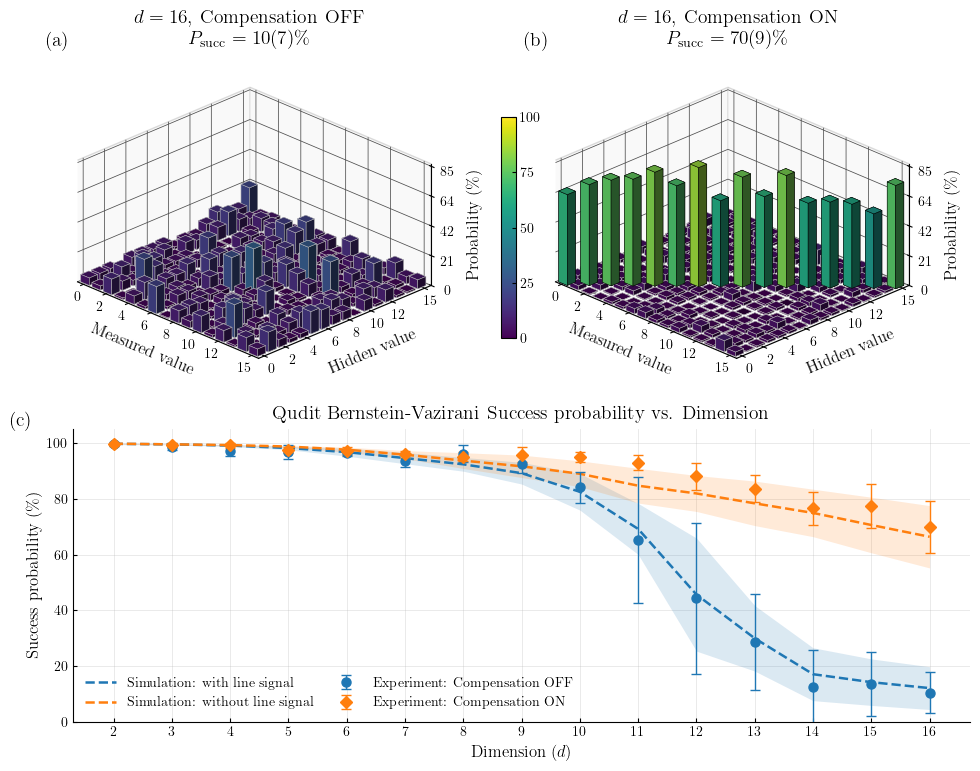

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# =========================================================
# STYLE
# =========================================================
rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 9,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# USER OPTIONS
# =========================================================
SAVE_FIGURE = True
OUTPUT_NAME = "BVA_summary_figure_3D.svg"

SHOW_TOP_COLORBAR = True
SHOW_BAR_VALUE_LABELS = False
MAX_TOP_TICK_LABELS = 7

# 3D camera angle
TOP_VIEW_ELEV = 25
TOP_VIEW_AZIM = -45

# Move the entire top block: both 3D plots + shared colorbar.
# Positive y moves up, negative y moves down.
TOP_BLOCK_SHIFT_Y = -0.05

# Move top 3D plots.
# Negative x moves left, positive x moves right.
# Positive y moves up, negative y moves down.
TOP_3D_COMMON_SHIFT_X = 0.00
TOP_3D_COMMON_SHIFT_Y = 0.00

LEFT_3D_SHIFT_X = -0.025
LEFT_3D_SHIFT_Y = 0.00

RIGHT_3D_SHIFT_X = -0.04
RIGHT_3D_SHIFT_Y = 0.00

# Optional resizing of top 3D plots.
# 1.00 keeps original size.
LEFT_3D_SCALE = 1.00
RIGHT_3D_SCALE = 1.00

# 3D title spacing.
# Smaller pad brings title closer to the 3D plot.
TOP_3D_TITLE_PAD = -1

# Label/tick spacing
X_LABEL_PAD = -1
Y_LABEL_PAD = -1
Z_LABEL_PAD = -5

X_TICK_PAD = -3
Y_TICK_PAD = -3
Z_TICK_PAD = -2

# Shared font sizes
TITLE_FONTSIZE = 14
AXIS_LABEL_FONTSIZE = 12
TICK_FONTSIZE = 10
LEGEND_FONTSIZE = 10
PANEL_LABEL_FONTSIZE = 14

# Colorbar fixed from 0 to 100%.
# The 3D z-axis is matched to the actual max of the two top datasets.
COLORBAR_MIN = 0.0
COLORBAR_MAX = 1.0

prep_mode_label = 'Short U1' if use_short_U1 else 'Full QFT'

plot_styles = {
    False: {
        'color': 'C0',
        'marker': 'o',
        'panel_label': 'Compensation OFF',
        'exp_label': 'Experiment: Compensation OFF',
        'sim_label': f'Simulation: with line signal',
    },
    True: {
        'color': 'C1',
        'marker': 'D',
        'panel_label': 'Compensation ON',
        'exp_label': 'Experiment: Compensation ON',
        'sim_label': f'Simulation: without line signal',
    },
}

# =========================================================
# LOOKUP TABLE
# =========================================================
result_lookup = {False: {}, True: {}}
for lt_value in [False, True]:
    for result in batch_results[lt_value]:
        result_lookup[lt_value][result['dimension']] = result

dims_off = set(dimensions_by_lt[False])
dims_on = set(dimensions_by_lt[True])
common_dimensions = sorted(dims_off & dims_on)

if len(common_dimensions) == 0:
    raise ValueError("No common dimension exists between AC/LS comp OFF and ON datasets.")

dim_plot = max(common_dimensions)

result_off = result_lookup[False].get(dim_plot)
result_on = result_lookup[True].get(dim_plot)

if result_off is None or result_on is None:
    raise ValueError(f"Missing data for d={dim_plot} in one of the compensation settings.")

data_off = np.asarray(result_off["data_m"], dtype=float)
data_on = np.asarray(result_on["data_m"], dtype=float)

# Shared z-axis maximum for both 3D plots
zmax = max(float(np.max(data_off)), float(np.max(data_on)), 1e-6)

# Colorbar normalization fixed from 0 to 100%
norm = Normalize(vmin=COLORBAR_MIN, vmax=COLORBAR_MAX)
cmap = plt.cm.viridis

# =========================================================
# HELPERS
# =========================================================
def add_panel_label(ax, label):
    if hasattr(ax, "text2D"):
        ax.text2D(
            -0.07, 1.01, label,
            transform=ax.transAxes,
            fontsize=PANEL_LABEL_FONTSIZE,
            fontweight='normal'
        )
    else:
        ax.text(
            -0.07, 1.01, label,
            transform=ax.transAxes,
            fontsize=PANEL_LABEL_FONTSIZE,
            fontweight='normal'
        )


def sparse_tick_positions(n, max_labels=7):
    if n <= max_labels:
        pos = np.arange(n)
    else:
        pos = np.unique(np.round(np.linspace(0, n - 1, max_labels)).astype(int))
    return pos


def shift_axis_position(ax, dx=0.0, dy=0.0, scale=1.0):
    """
    Move and optionally resize an axis.

    dx > 0 moves right, dx < 0 moves left.
    dy > 0 moves up, dy < 0 moves down.
    scale > 1 enlarges around the axis center.
    """
    pos = ax.get_position()

    cx = pos.x0 + 0.5 * pos.width
    cy = pos.y0 + 0.5 * pos.height

    new_width = pos.width * scale
    new_height = pos.height * scale

    new_x0 = cx - 0.5 * new_width + dx
    new_y0 = cy - 0.5 * new_height + dy

    ax.set_position([new_x0, new_y0, new_width, new_height])


def apply_top_3d_position_adjustments(ax_left, ax_right):
    shift_axis_position(
        ax_left,
        dx=TOP_3D_COMMON_SHIFT_X + LEFT_3D_SHIFT_X,
        dy=TOP_BLOCK_SHIFT_Y + TOP_3D_COMMON_SHIFT_Y + LEFT_3D_SHIFT_Y,
        scale=LEFT_3D_SCALE
    )

    shift_axis_position(
        ax_right,
        dx=TOP_3D_COMMON_SHIFT_X + RIGHT_3D_SHIFT_X,
        dy=TOP_BLOCK_SHIFT_Y + TOP_3D_COMMON_SHIFT_Y + RIGHT_3D_SHIFT_Y,
        scale=RIGHT_3D_SCALE
    )


def style_3d_axis(ax):
    ax.view_init(elev=TOP_VIEW_ELEV, azim=TOP_VIEW_AZIM)

    try:
        ax.set_proj_type("ortho")
    except Exception:
        pass

    pane_color = (0.96, 0.96, 0.96, 1.0)
    pane_edge = (0.72, 0.72, 0.72, 1.0)

    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.pane.fill = True
        axis.pane.set_facecolor(pane_color)
        axis.pane.set_edgecolor(pane_edge)

    ax.grid(True)

    try:
        for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
            axis._axinfo["grid"]["linewidth"] = 0.55
            axis._axinfo["grid"]["linestyle"] = "-"
            axis._axinfo["grid"]["color"] = (0.30, 0.30, 0.30, 1.0)
    except Exception:
        pass

    try:
        ax.xaxis.line.set_linewidth(0.8)
        ax.yaxis.line.set_linewidth(0.8)
        ax.zaxis.line.set_linewidth(0.8)
    except Exception:
        pass

    ax.tick_params(axis='x', pad=X_TICK_PAD, labelsize=TICK_FONTSIZE)
    ax.tick_params(axis='y', pad=Y_TICK_PAD, labelsize=TICK_FONTSIZE)
    ax.tick_params(axis='z', pad=Z_TICK_PAD, labelsize=TICK_FONTSIZE)

    try:
        ax.set_box_aspect((1.05, 1.0, 0.55), zoom=1.03)
    except Exception:
        ax.set_box_aspect((1.05, 1.0, 0.55))


def draw_bva_3d(ax, data_m, result, lt_value):
    n_rows, n_cols = data_m.shape

    xpos, ypos = np.meshgrid(np.arange(n_cols), np.arange(n_rows))
    xpos = xpos.ravel()
    ypos = ypos.ravel()
    zpos = np.zeros_like(xpos, dtype=float)

    dx = 0.76 * np.ones_like(xpos, dtype=float)
    dy = 0.76 * np.ones_like(ypos, dtype=float)
    dz = data_m.ravel()

    colors = cmap(norm(dz))

    # ax.bar3d(
    #     xpos, ypos, zpos, dx, dy, dz,
    #     color=colors,
    #     shade=True,
    #     edgecolor=["black" if z > 0.40 else "0.75" for z in dz],
    #     linewidth=0.3,
    #     zsort='average'
    # )


    from matplotlib.colors import to_rgba

    edgecolors_per_bar = [
        to_rgba("black") if z > 0.40 else to_rgba("0.75")
        for z in dz
    ]
    edgecolors_per_face = np.repeat(edgecolors_per_bar, 6, axis=0)

    ax.bar3d(
        xpos, ypos, zpos, dx, dy, dz,
        color=colors,
        shade=True,
        edgecolor=edgecolors_per_face,
        linewidth=0.35,
        zsort='average'
    )

    hidden_values = result["hidden_values"]
    measured_dim = data_m.shape[1]

    xticks = np.array([0, 2, 4, 6, 8, 10, 12, 15])
    yticks = np.array([0, 2, 4, 6, 8, 10, 12, 15])

    ax.set_xticks(xticks + 0.38)
    ax.set_xticklabels([rf"${v}$" for v in xticks], fontsize=TICK_FONTSIZE)

    ax.set_yticks(yticks + 0.38)
    ax.set_yticklabels([rf"${hidden_values[v]}$" for v in yticks], fontsize=TICK_FONTSIZE)

    ax.set_xlim(-0.15, n_cols)
    ax.set_ylim(-0.15, n_rows)

    ax.set_zlim(0, zmax * 1.02)
    zticks = np.linspace(0, zmax, 5)
    ax.set_zticks(zticks)
    ax.set_zticklabels([rf"${100*tick:.0f}$" for tick in zticks], fontsize=TICK_FONTSIZE)

    ax.set_xlabel(r"Measured value", labelpad=X_LABEL_PAD, fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_ylabel(r"Hidden value", labelpad=Y_LABEL_PAD, fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_zlabel(r"Probability (\%)", labelpad=Z_LABEL_PAD, fontsize=AXIS_LABEL_FONTSIZE)

    avg_success = np.round(100.0 * result["avg_success_probability"])
    hidden_value_std = np.round(100.0 * result["hidden_value_std"])
    ax.set_title(
        rf"$d={result['dimension']}$, {plot_styles[lt_value]['panel_label']}" + "\n" +
        rf"$P_{{\mathrm{{succ}}}} = {int(avg_success)}({int(hidden_value_std)})\%$",
        fontsize=TITLE_FONTSIZE,
        fontweight="normal",
        pad=TOP_3D_TITLE_PAD
    )

    if SHOW_BAR_VALUE_LABELS:
        for x, y, h in zip(xpos, ypos, dz):
            if h < 0.10:
                continue
            ax.text(
                x + 0.38, y + 0.38, h + 0.015 * zmax,
                rf"{100*h:.0f}",
                ha='center',
                va='bottom',
                fontsize=max(5, int(90 / result["dimension"]))
            )

    style_3d_axis(ax)


def draw_success_panel(ax):
    for lt_value in [False, True]:
        style = plot_styles[lt_value]

        dims_exp = np.asarray(dimensions_by_lt[lt_value], dtype=float)
        avg_exp = 100.0 * np.asarray(avg_success_probability_by_lt[lt_value], dtype=float)
        exp_err = 100.0 * np.asarray(experimental_error_by_lt[lt_value], dtype=float)

        if len(dims_exp) > 0:
            ax.errorbar(
                dims_exp,
                avg_exp,
                yerr=exp_err,
                linestyle='',
                marker=style['marker'],
                markersize=6.5,
                capsize=3.5,
                color=style['color'],
                elinewidth=1.0,
                label=style['exp_label'],
                zorder=4,
            )

        dims_sim = np.asarray(simulation_overlay_results[lt_value]['dimensions'], dtype=float)
        avg_sim = 100.0 * np.asarray(simulation_overlay_results[lt_value]['avg_success_probability'], dtype=float)
        std_sim = 100.0 * np.asarray(simulation_overlay_results[lt_value]['std_success_probability'], dtype=float)

        ax.plot(
            dims_sim,
            avg_sim,
            linestyle='--',
            linewidth=1.8,
            color=style['color'],
            label=style['sim_label'],
            zorder=3,
        )

        ax.fill_between(
            dims_sim,
            avg_sim - std_sim,
            avg_sim + std_sim,
            color=style['color'],
            alpha=0.16,
            linewidth=0,
            zorder=2,
        )

    xticks_all = sorted(
        set(simulation_overlay_results[False]['dimensions']) |
        set(simulation_overlay_results[True]['dimensions']) |
        set(dimensions_by_lt[False]) |
        set(dimensions_by_lt[True])
    )

    ax.set_title(
        r"Qudit Bernstein-Vazirani Success probability vs. Dimension",
        fontsize=TITLE_FONTSIZE,
        fontweight="normal",
        pad=7
    )

    ax.set_xticks(xticks_all)
    ax.set_xlabel(r"Dimension ($d$)", fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_ylabel(r"Success probability (\%)", fontsize=AXIS_LABEL_FONTSIZE)
    ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)

    ax.set_ylim(0, 105)

    ax.grid(True, axis='both', alpha=0.30, linewidth=0.6)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.legend(
        fontsize=LEGEND_FONTSIZE,
        ncol=2,
        frameon=False,
        loc='lower left',
        handlelength=2.2,
        columnspacing=1.2
    )


def add_shared_top_colorbar(fig, ax_left, ax_right):
    if not SHOW_TOP_COLORBAR:
        return

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    pos1 = ax_left.get_position()
    pos2 = ax_right.get_position()

    cbar_width = 0.014
    cbar_height = 0.62 * min(pos1.height, pos2.height)

    cbar_x = 0.52 * (pos1.x1 + pos2.x0) - 0.5 * cbar_width
    cbar_y = pos1.y0 + 0.5 * (pos1.height - cbar_height)

    cbar_ax = fig.add_axes([cbar_x, cbar_y, cbar_width, cbar_height])
    cbar = fig.colorbar(sm, cax=cbar_ax)

    ticks = np.linspace(0, 1, 5)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([rf"${100*tick:.0f}$" for tick in ticks])

    cbar.ax.tick_params(labelsize=TICK_FONTSIZE)


# =========================================================
# FIGURE LAYOUT
# =========================================================
fig = plt.figure(figsize=(10.2, 8.3))

gs = GridSpec(
    2, 2,
    figure=fig,
    height_ratios=[1.0, 0.82],
    hspace=0.20,
    wspace=0.22
)

ax1 = fig.add_subplot(gs[0, 0], projection='3d')
ax2 = fig.add_subplot(gs[0, 1], projection='3d')
ax3 = fig.add_subplot(gs[1, :])

# =========================================================
# TOP PANELS
# =========================================================
draw_bva_3d(ax1, data_off, result_off, False)
draw_bva_3d(ax2, data_on, result_on, True)

# =========================================================
# BOTTOM PANEL
# =========================================================
draw_success_panel(ax3)

# =========================================================
# PANEL LABELS
# =========================================================
add_panel_label(ax1, '(a)')
add_panel_label(ax2, '(b)')
add_panel_label(ax3, '(c)')

# =========================================================
# FINAL LAYOUT
# =========================================================
plt.subplots_adjust(left=0.08, right=0.96, top=0.96, bottom=0.10)

# Move/resize top 3D axes after layout adjustment
# and before adding the shared colorbar.
apply_top_3d_position_adjustments(ax1, ax2)

# Add shared colorbar after moving the 3D plots,
# so it remains centered vertically with them.
add_shared_top_colorbar(fig, ax1, ax2)

if SAVE_FIGURE:
    plt.savefig(OUTPUT_NAME, bbox_inches='tight', pad_inches=0.0)
    plt.savefig(OUTPUT_NAME.replace(".svg", ".pdf"), bbox_inches="tight", pad_inches=0.0, dpi=300)

plt.show()